# Define maze dataset

In [1]:
import numpy as np
import pandas as pd
import subprocess
from pathlib import Path

In [2]:
MAZE_LAYOUTS = {
    "OPEN": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "U_MAZE": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 0, 1, 1, 1, 1, 1], [1, 1, 0, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "U_MAZE_EVAL": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 0, 1, 1], [1, 1, 1, 1, 1, 0, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "SMALL_MAZE": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 0, 0, 0, 0, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "MEDIUM_MAZE": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 1, 1, 0, 0, 1], [1, 0, 0, 0, 1, 0, 0, 1], [1, 1, 1, 0, 0, 0, 1, 1], [1, 0, 0, 0, 1, 0, 0, 1], [1, 0, 1, 0, 0, 1, 0, 1], [1, 0, 0, 1, 0, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "MEDIUM_MAZE_EVAL": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 0, 0, 0, 0, 1], [1, 0, 1, 1, 0, 1, 0, 1], [1, 0, 1, 0, 0, 0, 0, 1], [1, 1, 1, 0, 0, 1, 1, 1], [1, 0, 0, 0, 0, 0, 0, 1], [1, 0, 0, 1, 1, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "LARGE_MAZE": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1], [1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1], [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1], [1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1], [1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1], [1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1], [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
    "LARGE_MAZE_EVAL": np.asarray([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], [1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1], [1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1], [1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1], [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1], [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1], [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.int32),
}


In [3]:
maze_names = np.array(list(MAZE_LAYOUTS.keys()), dtype="<U32")
grid_shapes = np.array([maze.shape for maze in MAZE_LAYOUTS.values()], dtype=np.int32)
mazes = np.empty(len(maze_names), dtype=object)
for index, maze_name in enumerate(maze_names):
    mazes[index] = MAZE_LAYOUTS[str(maze_name)].copy()


In [4]:
dataset_path = Path("maze2d_discrete_8x8_dataset_v2.npz")
np.savez(
    dataset_path,
    maze_names=np.array(maze_names, dtype="<U32"),
    mazes=mazes,
    grid_shapes=grid_shapes,
)

print(dataset_path)


maze2d_discrete_8x8_dataset_v2.npz


# Get trajectory data to feed into transformers

In [5]:
OUTPUT_DATASET = Path("maze2d_all_mazes_transformer_ready_4act.npz")
PAD_TOKEN_ID = 0
ACTION_TOKEN_NAMES = np.array(["UP", "DOWN", "LEFT", "RIGHT"])
ACTION_DELTAS = np.asarray(
    [
        [0, 1],
        [0, -1],
        [-1, 0],
        [1, 0],
    ],
    dtype=np.int8,
)
TOKEN_TYPE_PAD = 0
TOKEN_TYPE_MAZE = 1
TOKEN_TYPE_START = 2
TOKEN_TYPE_GOAL = 3
TOKEN_TYPE_STATE = 4
TOKEN_TYPE_ACTION = 5

In [6]:
def cell_to_state_index(cell_xy: np.ndarray, global_grid_shape: tuple[int, int]) -> int:
    return int(cell_xy[0]) * int(global_grid_shape[1]) + int(cell_xy[1])


def bfs_shortest_path(maze: np.ndarray, start: tuple[int, int], goal: tuple[int, int]) -> np.ndarray | None:
    if start == goal:
        return np.asarray([start], dtype=np.int16)

    rows, cols = maze.shape
    queue: deque[tuple[int, int]] = deque([start])
    parents: dict[tuple[int, int], tuple[int, int] | None] = {start: None}
    neighbor_order = ((0, 1), (0, -1), (-1, 0), (1, 0))

    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for dx, dy in neighbor_order:
            nxt = (current[0] + dx, current[1] + dy)
            inside = 0 <= nxt[0] < rows and 0 <= nxt[1] < cols
            if not inside or maze[nxt] != 0 or nxt in parents:
                continue
            parents[nxt] = current
            queue.append(nxt)

    if goal not in parents:
        return None

    path_rev = []
    node: tuple[int, int] | None = goal
    while node is not None:
        path_rev.append(node)
        node = parents[node]
    path_rev.reverse()
    return np.asarray(path_rev, dtype=np.int16)


def build_tokenized_episode(
    maze_token_id: int,
    path_cells: np.ndarray,
    goal_cell: np.ndarray,
    global_grid_shape: tuple[int, int],
    state_token_offset: int,
    action_token_offset: int,
) -> dict[str, np.ndarray | int]:
    def state_token(cell_xy: np.ndarray) -> int:
        return state_token_offset + cell_to_state_index(cell_xy, global_grid_shape)

    obs_xy = np.asarray(path_cells, dtype=np.int16)
    actions = np.diff(obs_xy, axis=0).astype(np.int8) if len(obs_xy) > 1 else np.zeros((0, 2), dtype=np.int8)
    action_delta_to_token = {
        tuple(int(v) for v in delta): int(action_token_offset + idx)
        for idx, delta in enumerate(ACTION_DELTAS)
    }

    input_ids = [maze_token_id, state_token(obs_xy[0]), state_token(goal_cell), state_token(obs_xy[0])]
    token_type_ids = [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE]
    labels = [-100, -100, -100, -100]

    for step in range(len(obs_xy) - 1):
        action_key = tuple(int(v) for v in actions[step])
        action_token = action_delta_to_token[action_key]
        next_state_token = state_token(obs_xy[step + 1])
        input_ids.extend([action_token, next_state_token])
        token_type_ids.extend([TOKEN_TYPE_ACTION, TOKEN_TYPE_STATE])
        labels.extend([action_token, -100])

    return {
        "input_ids": np.asarray(input_ids, dtype=np.int32),
        "labels": np.asarray(labels, dtype=np.int32),
        "token_type_ids": np.asarray(token_type_ids, dtype=np.int8),
        "sequence_length": int(len(input_ids)),
        "path_length": int(len(obs_xy)),
    }

In [7]:
dataset = np.load(dataset_path, allow_pickle=True)
maze_names = np.asarray(dataset["maze_names"])
mazes = dataset["mazes"]
grid_shapes = np.asarray(dataset["grid_shapes"], dtype=np.int32)
num_mazes = int(len(maze_names))
global_grid_shape = (
    int(grid_shapes[:, 0].max()),
    int(grid_shapes[:, 1].max()),
)

maze_token_offset = 1
state_token_offset = maze_token_offset + num_mazes
num_state_tokens = int(global_grid_shape[0] * global_grid_shape[1])
action_token_offset = state_token_offset + num_state_tokens
vocab_size = action_token_offset + len(ACTION_DELTAS)

episode_input_ids: list[np.ndarray] = []
episode_labels: list[np.ndarray] = []
episode_token_types: list[np.ndarray] = []
sequence_lengths: list[int] = []
path_lengths: list[int] = []
maze_indices: list[int] = []
maze_name_per_episode: list[str] = []
grid_shape_per_episode: list[np.ndarray] = []
start_cells: list[np.ndarray] = []
goal_cells: list[np.ndarray] = []
paths_xy: list[np.ndarray] = []

episode_id = 0
connected_pair_count = 0
skipped_pair_count = 0

In [8]:
from collections import deque
for maze_index, (maze_name, maze_obj, grid_shape) in enumerate(zip(maze_names, mazes, grid_shapes)):
        maze = np.asarray(maze_obj, dtype=np.int8)
        free_cells = np.argwhere(maze == 0).astype(np.int16)
        maze_token_id = int(maze_token_offset + maze_index)

       
        for start_cell in free_cells:
            for goal_cell in free_cells:
                if np.array_equal(start_cell, goal_cell):
                    continue

                path_cells = bfs_shortest_path(
                    maze=maze,
                    start=tuple(int(v) for v in start_cell),
                    goal=tuple(int(v) for v in goal_cell),
                )
                if path_cells is None:
                    skipped_pair_count += 1
                    continue

                packed = build_tokenized_episode(
                    maze_token_id=maze_token_id,
                    path_cells=path_cells,
                    goal_cell=np.asarray(goal_cell, dtype=np.int16),
                    global_grid_shape=global_grid_shape,
                    state_token_offset=state_token_offset,
                    action_token_offset=action_token_offset,
                )
                episode_input_ids.append(packed["input_ids"])
                episode_labels.append(packed["labels"])
                episode_token_types.append(packed["token_type_ids"])
                sequence_lengths.append(int(packed["sequence_length"]))
                path_lengths.append(int(packed["path_length"]))
                maze_indices.append(int(maze_index))
                maze_name_per_episode.append(str(maze_name))
                grid_shape_per_episode.append(np.asarray(grid_shape, dtype=np.int32))
                start_cells.append(np.asarray(start_cell, dtype=np.int16))
                goal_cells.append(np.asarray(goal_cell, dtype=np.int16))
                paths_xy.append(np.asarray(path_cells, dtype=np.int16))
                connected_pair_count += 1
                episode_id += 1

sequence_lengths_arr = np.asarray(sequence_lengths, dtype=np.int32)
max_seq_len = int(sequence_lengths_arr.max())
num_episodes = int(len(episode_input_ids))

input_ids = np.full((num_episodes, max_seq_len), PAD_TOKEN_ID, dtype=np.int32)
labels = np.full((num_episodes, max_seq_len), -100, dtype=np.int32)
attention_mask = np.zeros((num_episodes, max_seq_len), dtype=np.int8)
token_type_ids = np.full((num_episodes, max_seq_len), TOKEN_TYPE_PAD, dtype=np.int8)

for idx in range(num_episodes):
    seq_len = int(sequence_lengths_arr[idx])
    input_ids[idx, :seq_len] = episode_input_ids[idx]
    labels[idx, :seq_len] = episode_labels[idx]
    token_type_ids[idx, :seq_len] = episode_token_types[idx]
    attention_mask[idx, :seq_len] = 1

np.savez_compressed(
    OUTPUT_DATASET,
    input_ids=input_ids,
    labels=labels,
    attention_mask=attention_mask,
    token_type_ids=token_type_ids,
    sequence_lengths=sequence_lengths_arr,
    path_lengths=np.asarray(path_lengths, dtype=np.int32),
    episode_ids=np.arange(num_episodes, dtype=np.int32),
    maze_indices=np.asarray(maze_indices, dtype=np.int32),
    maze_names=maze_names.astype("<U32"),
    maze_name_per_episode=np.asarray(maze_name_per_episode, dtype="<U32"),
    maze_token_ids=np.arange(maze_token_offset, maze_token_offset + num_mazes, dtype=np.int32),
    mazes=mazes,
    grid_shapes=grid_shapes.astype(np.int32),
    grid_shape_per_episode=np.asarray(grid_shape_per_episode, dtype=np.int32),
    start_cells=np.asarray(start_cells, dtype=np.int16),
    goal_cells=np.asarray(goal_cells, dtype=np.int16),
    paths_xy=np.asarray(paths_xy, dtype=object),
    pad_token_id=np.asarray([PAD_TOKEN_ID], dtype=np.int32),
    vocab_size=np.asarray([vocab_size], dtype=np.int32),
    maze_token_offset=np.asarray([maze_token_offset], dtype=np.int32),
    state_token_offset=np.asarray([state_token_offset], dtype=np.int32),
    action_token_offset=np.asarray([action_token_offset], dtype=np.int32),
    global_grid_shape=np.asarray(global_grid_shape, dtype=np.int32),
    action_token_names=ACTION_TOKEN_NAMES,
    action_deltas=ACTION_DELTAS,
    token_type_pad=np.asarray([TOKEN_TYPE_PAD], dtype=np.int8),
    token_type_maze=np.asarray([TOKEN_TYPE_MAZE], dtype=np.int8),
    token_type_start=np.asarray([TOKEN_TYPE_START], dtype=np.int8),
    token_type_goal=np.asarray([TOKEN_TYPE_GOAL], dtype=np.int8),
    token_type_state=np.asarray([TOKEN_TYPE_STATE], dtype=np.int8),
    token_type_action=np.asarray([TOKEN_TYPE_ACTION], dtype=np.int8),
)


print("output_dataset:", OUTPUT_DATASET)
print("num_mazes:", num_mazes)
print("maze_names:", [str(name) for name in maze_names])
print("global_grid_shape:", global_grid_shape)
print("num_episodes:", num_episodes)
print("connected_pair_count:", connected_pair_count)
print("skipped_pair_count:", skipped_pair_count)
print("max_seq_len:", max_seq_len)
print("vocab_size:", vocab_size)

output_dataset: maze2d_all_mazes_transformer_ready_4act.npz
num_mazes: 8
maze_names: ['OPEN', 'U_MAZE', 'U_MAZE_EVAL', 'SMALL_MAZE', 'MEDIUM_MAZE', 'MEDIUM_MAZE_EVAL', 'LARGE_MAZE', 'LARGE_MAZE_EVAL']
global_grid_shape: (9, 12)
num_episodes: 5976
connected_pair_count: 5976
skipped_pair_count: 32
max_seq_len: 42
vocab_size: 121


In [9]:
NUM_FOLDS = 5

SOURCE_DATASET = Path("maze2d_all_mazes_transformer_ready_4act.npz")
OUTPUT_DATASET = Path("maze2d_all_mazes_transformer_ready_4act_cv5.npz")

data = np.load(SOURCE_DATASET, allow_pickle=True)
files = list(data.files)
files

['input_ids',
 'labels',
 'attention_mask',
 'token_type_ids',
 'sequence_lengths',
 'path_lengths',
 'episode_ids',
 'maze_indices',
 'maze_names',
 'maze_name_per_episode',
 'maze_token_ids',
 'mazes',
 'grid_shapes',
 'grid_shape_per_episode',
 'start_cells',
 'goal_cells',
 'paths_xy',
 'pad_token_id',
 'vocab_size',
 'maze_token_offset',
 'state_token_offset',
 'action_token_offset',
 'global_grid_shape',
 'action_token_names',
 'action_deltas',
 'token_type_pad',
 'token_type_maze',
 'token_type_start',
 'token_type_goal',
 'token_type_state',
 'token_type_action']

In [10]:
data = np.load(SOURCE_DATASET, allow_pickle=True)
files = list(data.files)

maze_name_per_episode = np.asarray(data["maze_name_per_episode"]).astype("<U32")
start_cells = np.asarray(data["start_cells"], dtype=np.int16)
goal_cells = np.asarray(data["goal_cells"], dtype=np.int16)
path_lengths = np.asarray(data["path_lengths"], dtype=np.int32)

num_episodes = int(len(maze_name_per_episode))
fold_ids = np.zeros(num_episodes, dtype=np.int32)

unique_mazes = list(dict.fromkeys(str(name) for name in maze_name_per_episode))
per_maze_rows: list[dict[str, object]] = []

for maze_name in unique_mazes:
    maze_idx = np.flatnonzero(maze_name_per_episode == maze_name)
    sort_order = np.lexsort(
        (
            goal_cells[maze_idx, 1],
            goal_cells[maze_idx, 0],
            start_cells[maze_idx, 1],
            start_cells[maze_idx, 0],
            path_lengths[maze_idx],
        )
    )
    maze_sorted_idx = maze_idx[sort_order]
    assigned_folds = np.arange(int(maze_sorted_idx.size), dtype=np.int32) % NUM_FOLDS
    fold_ids[maze_sorted_idx] = assigned_folds

    per_maze_rows.append(
        {
            "maze_name": maze_name,
            "total": int(maze_sorted_idx.size),
            "fold_counts": [int(np.sum(assigned_folds == fold)) for fold in range(NUM_FOLDS)],
        }
    )

out: dict[str, np.ndarray] = {key: data[key] for key in files}
out["fold_ids"] = fold_ids
out["cv_num_folds"] = np.asarray([NUM_FOLDS], dtype=np.int32)
out["cv_split_method"] = np.asarray(["round_robin_lexsorted_per_maze"], dtype="<U64")

np.savez_compressed(OUTPUT_DATASET, **out)

print("source_dataset:", SOURCE_DATASET)
print("output_dataset:", OUTPUT_DATASET)
print("cv_num_folds:", NUM_FOLDS)
print("cv_split_method: round_robin_lexsorted_per_maze")
print("num_episodes:", num_episodes)
for row in per_maze_rows:
    print(row)

source_dataset: maze2d_all_mazes_transformer_ready_4act.npz
output_dataset: maze2d_all_mazes_transformer_ready_4act_cv5.npz
cv_num_folds: 5
cv_split_method: round_robin_lexsorted_per_maze
num_episodes: 5976
{'maze_name': 'OPEN', 'total': 240, 'fold_counts': [48, 48, 48, 48, 48]}
{'maze_name': 'U_MAZE', 'total': 90, 'fold_counts': [18, 18, 18, 18, 18]}
{'maze_name': 'U_MAZE_EVAL', 'total': 90, 'fold_counts': [18, 18, 18, 18, 18]}
{'maze_name': 'SMALL_MAZE', 'total': 24, 'fold_counts': [5, 5, 5, 5, 4]}
{'maze_name': 'MEDIUM_MAZE', 'total': 650, 'fold_counts': [130, 130, 130, 130, 130]}
{'maze_name': 'MEDIUM_MAZE_EVAL', 'total': 650, 'fold_counts': [130, 130, 130, 130, 130]}
{'maze_name': 'LARGE_MAZE', 'total': 2070, 'fold_counts': [414, 414, 414, 414, 414]}
{'maze_name': 'LARGE_MAZE_EVAL', 'total': 2162, 'fold_counts': [433, 433, 432, 432, 432]}


In [11]:
from __future__ import annotations

import argparse
import json
import math
import random
import sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [12]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


class MazeTokenDataset(Dataset):
    def __init__(self, npz_path: Path, indices: np.ndarray) -> None:
        data = np.load(npz_path, allow_pickle=True)
        self.input_ids = torch.from_numpy(data["input_ids"][indices].astype(np.int64))
        self.labels = torch.from_numpy(data["labels"][indices].astype(np.int64))
        self.attention_mask = torch.from_numpy(data["attention_mask"][indices].astype(np.bool_))
        self.token_type_ids = torch.from_numpy(data["token_type_ids"][indices].astype(np.int64))
        self.sequence_lengths = torch.from_numpy(data["sequence_lengths"][indices].astype(np.int64))
        self.episode_ids = torch.from_numpy(data["episode_ids"][indices].astype(np.int64))

        self.vocab_size = int(data["vocab_size"][0])
        self.pad_token_id = int(data["pad_token_id"][0])
        self.state_token_offset = int(data["state_token_offset"][0])
        self.action_token_offset = int(data["action_token_offset"][0])
        grid_key = "grid_shape" if "grid_shape" in data.files else "global_grid_shape"
        self.grid_shape = tuple(int(v) for v in data[grid_key])
        self.action_token_names = [str(v) for v in data["action_token_names"]]
        self.action_deltas = np.asarray(data["action_deltas"], dtype=np.int64)
    def __len__(self) -> int:
        return int(self.input_ids.shape[0])

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        return {
            "input_ids": self.input_ids[idx],
            "labels": self.labels[idx],
            "attention_mask": self.attention_mask[idx],
            "token_type_ids": self.token_type_ids[idx],
            "sequence_lengths": self.sequence_lengths[idx],
            "episode_id": self.episode_ids[idx],
        }

In [13]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int) -> None:
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1)]

In [14]:
class TinyCausalTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_seq_len: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        num_token_types: int = 6,
    ) -> None:
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.type_embed = nn.Embedding(num_token_types, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=max_seq_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(
        self,
        input_ids: torch.Tensor,
        token_type_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        x = self.token_embed(input_ids) + self.type_embed(token_type_ids)
        x = self.pos_encoder(x)
        seq_len = input_ids.size(1)
        causal_mask = torch.triu(
            torch.ones((seq_len, seq_len), dtype=torch.bool, device=input_ids.device),
            diagonal=1,
        )
        x = self.encoder(x, mask=causal_mask, src_key_padding_mask=~attention_mask)
        x = self.norm(x)
        return self.lm_head(x)

In [15]:
@dataclass
class EvalMetrics:
    loss: float
    action_accuracy: float


def shifted_loss_and_accuracy(
    logits: torch.Tensor,
    labels: torch.Tensor,
    ignore_index: int = -100,
) -> tuple[torch.Tensor, float]:
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    loss = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        ignore_index=ignore_index,
    )
    with torch.no_grad():
        valid = shift_labels != ignore_index
        if valid.any():
            preds = shift_logits.argmax(dim=-1)
            acc = (preds[valid] == shift_labels[valid]).float().mean().item()
        else:
            acc = float("nan")
    return loss, acc

In [16]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
) -> EvalMetrics:
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_acc = 0.0
    steps = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)

        with torch.set_grad_enabled(training):
            logits = model(input_ids=input_ids, token_type_ids=token_type_ids, attention_mask=attention_mask)
            loss, acc = shifted_loss_and_accuracy(logits, labels)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        total_loss += float(loss.item())
        total_acc += float(acc)
        steps += 1

    return EvalMetrics(loss=total_loss / max(steps, 1), action_accuracy=total_acc / max(steps, 1))


In [17]:
def decode_token(token_id: int, action_token_offset: int, action_token_names: list[str]) -> str:
    if token_id < action_token_offset:
        return f"STATE_{token_id}"
    return f"ACTION_{action_token_names[token_id - action_token_offset]}"


def greedy_generate_actions(
    model: TinyCausalTransformer,
    dataset: MazeTokenDataset,
    device: torch.device,
    episode_index: int,
    max_steps: int = 16,
) -> dict[str, object]:
    input_ids_full = dataset.input_ids[episode_index].numpy()
    labels_full = dataset.labels[episode_index].numpy()
    token_types_full = dataset.token_type_ids[episode_index].numpy()
    seq_len = int(dataset.sequence_lengths[episode_index].item())

    action_positions = np.flatnonzero(labels_full[:seq_len] != -100)
    prompt_end = 4  # [MAZE, START, GOAL, STATE_0]
    generated = input_ids_full[:prompt_end].tolist()
    generated_types = token_types_full[:prompt_end].tolist()
    target_actions = []
    pred_actions = []

    model.eval()
    for step_idx, action_pos in enumerate(action_positions[:max_steps]):
        x = torch.tensor([generated], dtype=torch.long, device=device)
        t = torch.tensor([generated_types], dtype=torch.long, device=device)
        m = torch.ones_like(x, dtype=torch.bool, device=device)
        with torch.no_grad():
            logits = model(input_ids=x, token_type_ids=t, attention_mask=m)
        action_logits = logits[0, -1, dataset.action_token_offset : dataset.action_token_offset + len(dataset.action_token_names)]
        next_token = int(dataset.action_token_offset + action_logits.argmax().item())
        target_token = int(labels_full[action_pos])
        pred_actions.append(next_token)
        target_actions.append(target_token)

        # Append predicted action, but keep the true next state as context so rollout stays on-manifold.
        generated.append(next_token)
        generated_types.append(5)
        next_state_pos = int(action_pos + 1)
        if next_state_pos >= seq_len:
            break
        generated.append(int(input_ids_full[next_state_pos]))
        generated_types.append(int(token_types_full[next_state_pos]))

    return {
        "episode_id": int(dataset.episode_ids[episode_index].item()),
        "target_action_tokens": target_actions,
        "pred_action_tokens": pred_actions,
        "target_actions_named": [
            decode_token(tok, dataset.action_token_offset, dataset.action_token_names) for tok in target_actions
        ],
        "pred_actions_named": [
            decode_token(tok, dataset.action_token_offset, dataset.action_token_names) for tok in pred_actions
        ],
    }

In [18]:
# Change only this value to run all training, decoding, tables and graphs on another dataset.
EXPERIMENT_DATASET = "mixed"  # "optimal" or "mixed"

EXPERIMENT_DATASETS = {
    "optimal": {
        "path": Path("maze2d_all_mazes_transformer_ready_4act_cv5.npz"),
        "run_tag": "cv5_4act19_all8",
    },
    "mixed": {
        "path": Path("maze2d_all_mazes_transformer_ready_mixed_4act_cv5.npz"),
        "run_tag": "cv5_organic_eps20_4act19_all8",
    },
}
if EXPERIMENT_DATASET not in EXPERIMENT_DATASETS:
    raise ValueError(f"Unknown EXPERIMENT_DATASET: {EXPERIMENT_DATASET!r}")

EXPERIMENT_CONFIG = EXPERIMENT_DATASETS[EXPERIMENT_DATASET]
EXPERIMENT_DATASET_PATH = EXPERIMENT_CONFIG["path"]
EXPERIMENT_RUN_TAG = EXPERIMENT_CONFIG["run_tag"]
TRAIN_DATASET_PATH = EXPERIMENT_DATASET_PATH
DEFAULT_CHECKPOINT_PATH = Path("checkpoints") / f"maze2d_discrete_transformer_tiny_{EXPERIMENT_DATASET}.pt"
print({"experiment_dataset": EXPERIMENT_DATASET, "path": str(EXPERIMENT_DATASET_PATH), "run_tag": EXPERIMENT_RUN_TAG})


def build_train_val_indices(
    dataset_path: Path,
    seed: int = 7,
    max_train_episodes: int = 4096,
    max_val_episodes: int = 512,
    use_predefined_split: bool = False,
    train_mask_key: str = "train_mask",
    val_mask_key: str = "eval_mask",
    cv_fold: int | None = None,
    fold_ids_key: str = "fold_ids",
) -> tuple[np.ndarray, np.ndarray]:
    data = np.load(dataset_path, allow_pickle=True)
    num_episodes = int(data["input_ids"].shape[0])

    if cv_fold is not None:
        if fold_ids_key not in data.files:
            raise KeyError(f"Requested cv fold split, but dataset is missing {fold_ids_key!r}.")
        fold_ids = np.asarray(data[fold_ids_key], dtype=np.int32)
        train_idx_all = np.flatnonzero(fold_ids != int(cv_fold))
        val_idx_all = np.flatnonzero(fold_ids == int(cv_fold))
        train_count = min(max_train_episodes, int(train_idx_all.size))
        val_count = min(max_val_episodes, int(val_idx_all.size))
        return train_idx_all[:train_count], val_idx_all[:val_count]

    if use_predefined_split:
        if train_mask_key not in data.files or val_mask_key not in data.files:
            raise KeyError(
                f"Requested predefined split, but dataset is missing {train_mask_key!r} or {val_mask_key!r}."
            )
        train_idx_all = np.flatnonzero(np.asarray(data[train_mask_key], dtype=np.bool_))
        val_idx_all = np.flatnonzero(np.asarray(data[val_mask_key], dtype=np.bool_))
        train_count = min(max_train_episodes, int(train_idx_all.size))
        val_count = min(max_val_episodes, int(val_idx_all.size))
        return train_idx_all[:train_count], val_idx_all[:val_count]

    perm = np.random.RandomState(seed).permutation(num_episodes)
    val_count = min(max_val_episodes, max(1, num_episodes // 10))
    train_count = min(max_train_episodes, num_episodes - val_count)
    train_idx = perm[:train_count]
    val_idx = perm[train_count : train_count + val_count]
    return train_idx, val_idx


def train_transformer_experiment(
    dataset_path: Path,
    output_path: Path,
    epochs: int = 12,
    batch_size: int = 128,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    d_model: int = 64,
    nhead: int = 4,
    num_layers: int = 2,
    ffn_dim: int = 128,
    dropout: float = 0.1,
    max_train_episodes: int = 4096,
    max_val_episodes: int = 512,
    use_predefined_split: bool = False,
    train_mask_key: str = "train_mask",
    val_mask_key: str = "eval_mask",
    cv_fold: int | None = None,
    fold_ids_key: str = "fold_ids",
    seed: int = 7,
    device: str = "cpu",
) -> dict[str, object]:
    set_seed(seed)
    torch_device = torch.device(device)

    train_idx, val_idx = build_train_val_indices(
        dataset_path=dataset_path,
        seed=seed,
        max_train_episodes=max_train_episodes,
        max_val_episodes=max_val_episodes,
        use_predefined_split=use_predefined_split,
        train_mask_key=train_mask_key,
        val_mask_key=val_mask_key,
        cv_fold=cv_fold,
        fold_ids_key=fold_ids_key,
    )

    train_ds = MazeTokenDataset(dataset_path, train_idx)
    val_ds = MazeTokenDataset(dataset_path, val_idx)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = TinyCausalTransformer(
        vocab_size=train_ds.vocab_size,
        max_seq_len=train_ds.input_ids.shape[1],
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=ffn_dim,
        dropout=dropout,
    ).to(torch_device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    print(
        json.dumps(
            {
                "dataset": str(dataset_path),
                "train_episodes": len(train_ds),
                "val_episodes": len(val_ds),
                "seq_len": int(train_ds.input_ids.shape[1]),
                "vocab_size": train_ds.vocab_size,
                "device": str(torch_device),
                "cv_fold": cv_fold,
            },
            indent=2,
        )
    )

    best_val = float("inf")
    best_checkpoint = None
    history: list[dict[str, float]] = []
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer, torch_device)
        val_metrics = run_epoch(model, val_loader, None, torch_device)
        row = {
            "epoch": float(epoch),
            "train_loss": train_metrics.loss,
            "train_action_accuracy": train_metrics.action_accuracy,
            "val_loss": val_metrics.loss,
            "val_action_accuracy": val_metrics.action_accuracy,
        }
        history.append(row)
        print(
            f"epoch {epoch:02d} | "
            f"train_loss={train_metrics.loss:.4f} train_acc={train_metrics.action_accuracy:.4f} | "
            f"val_loss={val_metrics.loss:.4f} val_acc={val_metrics.action_accuracy:.4f}"
        )
        if val_metrics.loss < best_val:
            best_val = val_metrics.loss
            best_checkpoint = {
                "model_state_dict": model.state_dict(),
                "model_config": {
                    "vocab_size": train_ds.vocab_size,
                    "max_seq_len": int(train_ds.input_ids.shape[1]),
                    "d_model": d_model,
                    "nhead": nhead,
                    "num_layers": num_layers,
                    "dim_feedforward": ffn_dim,
                    "dropout": dropout,
                },
                "history": list(history),
            }
            output_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(best_checkpoint, output_path)

    preview = greedy_generate_actions(model, val_ds, torch_device, episode_index=0)
    print("preview rollout:", json.dumps(preview, indent=2))
    print("saved checkpoint:", output_path)

    return {
        "model": model,
        "train_dataset": train_ds,
        "val_dataset": val_ds,
        "history": history,
        "best_checkpoint": best_checkpoint,
        "output_path": output_path,
        "preview": preview,
        "device": torch_device,
    }


{'experiment_dataset': 'mixed', 'path': 'maze2d_all_mazes_transformer_ready_mixed_4act_cv5.npz', 'run_tag': 'cv5_organic_eps20_4act19_all8'}


In [19]:
single_run = train_transformer_experiment(
    dataset_path=TRAIN_DATASET_PATH,
    output_path=DEFAULT_CHECKPOINT_PATH,
    epochs=20,
    batch_size=128,
    lr=3e-4,
    weight_decay=1e-4,
    d_model=64,
    nhead=4,
    num_layers=2,
    ffn_dim=128,
    dropout=0.1,
    max_train_episodes=4096,
    max_val_episodes=512,
    seed=7,
    device="cpu",
)


{
  "dataset": "maze2d_all_mazes_transformer_ready_mixed_4act_cv5.npz",
  "train_episodes": 4096,
  "val_episodes": 512,
  "seq_len": 42,
  "vocab_size": 121,
  "device": "cpu",
  "cv_fold": null
}
epoch 01 | train_loss=3.6179 train_acc=0.1906 | val_loss=2.5462 val_acc=0.3085
epoch 02 | train_loss=2.1567 train_acc=0.3104 | val_loss=1.7737 val_acc=0.3249
epoch 03 | train_loss=1.6113 train_acc=0.3723 | val_loss=1.4050 val_acc=0.4359
epoch 04 | train_loss=1.3088 train_acc=0.4709 | val_loss=1.1641 val_acc=0.5334
epoch 05 | train_loss=1.1288 train_acc=0.5496 | val_loss=1.0358 val_acc=0.5952
epoch 06 | train_loss=1.0327 train_acc=0.5915 | val_loss=0.9590 val_acc=0.6271
epoch 07 | train_loss=0.9720 train_acc=0.6158 | val_loss=0.9055 val_acc=0.6495
epoch 08 | train_loss=0.9274 train_acc=0.6336 | val_loss=0.8606 val_acc=0.6665
epoch 09 | train_loss=0.8918 train_acc=0.6453 | val_loss=0.8286 val_acc=0.6773
epoch 10 | train_loss=0.8597 train_acc=0.6590 | val_loss=0.8034 val_acc=0.6812
epoch 11 | t

In [20]:
CV_DATASET_PATH = EXPERIMENT_DATASET_PATH
CV_CHECKPOINT_DIR = Path("checkpoints")
CV_FOLDS = range(5)
DEFAULT_MAZES = ["OPEN", "U_MAZE", "U_MAZE_EVAL", "SMALL_MAZE", "MEDIUM_MAZE", "MEDIUM_MAZE_EVAL", "LARGE_MAZE", "LARGE_MAZE_EVAL"]
TOKEN_TYPE_MAZE = 1
TOKEN_TYPE_START = 2
TOKEN_TYPE_GOAL = 3
TOKEN_TYPE_STATE = 4
TOKEN_TYPE_ACTION = 5


def load_model_from_checkpoint(checkpoint_path: Path) -> tuple[TinyCausalTransformer, dict[str, int | float]]:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    model = TinyCausalTransformer(**checkpoint["model_config"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint["model_config"]


def state_token(cell_xy: np.ndarray, state_token_offset: int, global_grid_shape: tuple[int, int]) -> int:
    return int(state_token_offset + int(cell_xy[0]) * global_grid_shape[1] + int(cell_xy[1]))


def valid_action_candidates(current_cell: np.ndarray, maze: np.ndarray) -> list[tuple[int, np.ndarray]]:
    deltas = np.asarray([[0, 1], [0, -1], [-1, 0], [1, 0]], dtype=np.int16)
    candidates: list[tuple[int, np.ndarray]] = []
    for action_idx, delta in enumerate(deltas):
        next_cell = current_cell + delta
        inside = 0 <= int(next_cell[0]) < maze.shape[0] and 0 <= int(next_cell[1]) < maze.shape[1]
        if inside and int(maze[int(next_cell[0]), int(next_cell[1])]) == 0:
            candidates.append((action_idx, next_cell.astype(np.int16)))
    return candidates


def batched_next_action_logits(
    model: TinyCausalTransformer,
    token_batches: list[list[int]],
    type_batches: list[list[int]],
    vocab_action_start: int,
    action_count: int,
) -> np.ndarray:
    max_len = max(len(tokens) for tokens in token_batches)
    input_ids = np.zeros((len(token_batches), max_len), dtype=np.int64)
    token_type_ids = np.zeros((len(token_batches), max_len), dtype=np.int64)
    attention_mask = np.zeros((len(token_batches), max_len), dtype=np.bool_)

    for row, (tokens, types) in enumerate(zip(token_batches, type_batches)):
        seq_len = len(tokens)
        input_ids[row, :seq_len] = np.asarray(tokens, dtype=np.int64)
        token_type_ids[row, :seq_len] = np.asarray(types, dtype=np.int64)
        attention_mask[row, :seq_len] = True

    with torch.no_grad():
        logits = model(
            input_ids=torch.from_numpy(input_ids),
            token_type_ids=torch.from_numpy(token_type_ids),
            attention_mask=torch.from_numpy(attention_mask),
        )

    last_logits = []
    for row, tokens in enumerate(token_batches):
        last_logits.append(logits[row, len(tokens) - 1, vocab_action_start : vocab_action_start + action_count].numpy())
    return np.asarray(last_logits, dtype=np.float32)


def greedy_decode_query(
    model: TinyCausalTransformer,
    maze_token_id: int,
    maze: np.ndarray,
    start_cell: np.ndarray,
    goal_cell: np.ndarray,
    state_token_offset: int,
    action_token_offset: int,
    global_grid_shape: tuple[int, int],
    max_steps: int,
) -> np.ndarray:
    path = [np.asarray(start_cell, dtype=np.int16)]
    tokens = [
        int(maze_token_id),
        state_token(start_cell, state_token_offset, global_grid_shape),
        state_token(goal_cell, state_token_offset, global_grid_shape),
        state_token(start_cell, state_token_offset, global_grid_shape),
    ]
    types = [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE]

    for _ in range(max_steps):
        action_logits = batched_next_action_logits(
            model,
            [tokens],
            [types],
            vocab_action_start=action_token_offset,
            action_count=4,
        )[0]
        best_idx, best_next = max(valid_action_candidates(path[-1], maze), key=lambda item: float(action_logits[item[0]]))
        tokens.extend([action_token_offset + best_idx, state_token(best_next, state_token_offset, global_grid_shape)])
        types.extend([TOKEN_TYPE_ACTION, TOKEN_TYPE_STATE])
        path.append(best_next)
        if np.array_equal(best_next, goal_cell):
            break
    return np.asarray(path, dtype=np.int16)


def beam_decode_query(
    model: TinyCausalTransformer,
    maze_token_id: int,
    maze: np.ndarray,
    start_cell: np.ndarray,
    goal_cell: np.ndarray,
    state_token_offset: int,
    action_token_offset: int,
    global_grid_shape: tuple[int, int],
    max_steps: int,
    beam_width: int,
) -> np.ndarray:
    start_state_token = state_token(start_cell, state_token_offset, global_grid_shape)
    goal_state_token = state_token(goal_cell, state_token_offset, global_grid_shape)
    beams = [
        {
            "tokens": [int(maze_token_id), start_state_token, goal_state_token, start_state_token],
            "types": [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE],
            "path": [np.asarray(start_cell, dtype=np.int16)],
            "score": 0.0,
            "done": False,
        }
    ]

    for _ in range(max_steps):
        active = [beam for beam in beams if not beam["done"]]
        if not active:
            break

        logits_batch = batched_next_action_logits(
            model,
            [beam["tokens"] for beam in active],
            [beam["types"] for beam in active],
            vocab_action_start=action_token_offset,
            action_count=4,
        )

        candidates: list[dict[str, object]] = []
        active_cursor = 0
        for beam in beams:
            if beam["done"]:
                candidates.append(beam)
                continue
            action_logits = logits_batch[active_cursor]
            active_cursor += 1
            for action_idx, next_cell in valid_action_candidates(np.asarray(beam["path"][-1], dtype=np.int16), maze):
                next_beam = {
                    "tokens": list(beam["tokens"]) + [action_token_offset + action_idx, state_token(next_cell, state_token_offset, global_grid_shape)],
                    "types": list(beam["types"]) + [TOKEN_TYPE_ACTION, TOKEN_TYPE_STATE],
                    "path": list(beam["path"]) + [np.asarray(next_cell, dtype=np.int16)],
                    "score": float(beam["score"]) + float(action_logits[action_idx]),
                    "done": bool(np.array_equal(next_cell, goal_cell)),
                }
                candidates.append(next_beam)

        beams = sorted(candidates, key=lambda beam: float(beam["score"]), reverse=True)[:beam_width]
        finished = [beam for beam in beams if bool(beam["done"])]
        if finished:
            return np.asarray(max(finished, key=lambda beam: float(beam["score"]))["path"], dtype=np.int16)

    return np.asarray(max(beams, key=lambda beam: float(beam["score"]))["path"], dtype=np.int16)


In [21]:
import time


def select_eval_queries(dataset: np.lib.npyio.NpzFile, maze_name: str, cv_fold: int, query_count: int) -> np.ndarray:
    maze_name_per_episode = np.asarray(dataset["maze_name_per_episode"]).astype("<U32")
    fold_ids = np.asarray(dataset["fold_ids"], dtype=np.int32)
    start_cells = np.asarray(dataset["start_cells"], dtype=np.int16)
    goal_cells = np.asarray(dataset["goal_cells"], dtype=np.int16)
    path_lengths = np.asarray(dataset["path_lengths"], dtype=np.int32)

    idx = np.flatnonzero((fold_ids == int(cv_fold)) & (maze_name_per_episode == maze_name))
    order = np.lexsort(
        (
            goal_cells[idx, 1],
            goal_cells[idx, 0],
            start_cells[idx, 1],
            start_cells[idx, 0],
            path_lengths[idx],
        )
    )
    return idx[order][:query_count]


def mean_steps_on_success(df: pd.DataFrame) -> float:
    successful = df.loc[df["goal_reached"], "steps_until_stop"]
    return float(successful.mean()) if len(successful) else float("nan")


def summarize_by_columns(results: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for keys, group in results.groupby(group_cols, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(group_cols, keys)}
        row.update(
            {
                "completion_rate": float(group["goal_reached"].mean()),
                "average_steps_to_goal": mean_steps_on_success(group),
                "average_compute_seconds": float(group["compute_seconds"].mean()),
                "average_seconds_per_step": float(group["seconds_per_step"].mean()),
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)


def benchmark_cv_fold_decoding(
    dataset_path: Path,
    checkpoint_path: Path,
    cv_fold: int,
    queries_per_maze: int = 10000,
    mazes_to_evaluate: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    dataset = np.load(dataset_path, allow_pickle=True)
    model, model_config = load_model_from_checkpoint(checkpoint_path)

    if mazes_to_evaluate is None:
        mazes_to_evaluate = list(DEFAULT_MAZES)

    mazes = [np.asarray(maze, dtype=np.int8) for maze in dataset["mazes"]]
    start_cells = np.asarray(dataset["start_cells"], dtype=np.int16)
    goal_cells = np.asarray(dataset["goal_cells"], dtype=np.int16)
    maze_indices = np.asarray(dataset["maze_indices"], dtype=np.int32)
    episode_ids = np.asarray(dataset["episode_ids"], dtype=np.int32)
    maze_token_ids = np.asarray(dataset["maze_token_ids"], dtype=np.int32)
    state_token_offset = int(dataset["state_token_offset"][0])
    action_token_offset = int(dataset["action_token_offset"][0])
    global_grid_shape = tuple(int(v) for v in np.asarray(dataset["global_grid_shape"], dtype=np.int32))
    transformer_max_rollout_steps = max((int(model_config["max_seq_len"]) - 4) // 2, 1)

    strategies = {
        "greedy": lambda **kwargs: greedy_decode_query(model=model, **kwargs),
        "beam_2": lambda **kwargs: beam_decode_query(model=model, beam_width=2, **kwargs),
        "beam_3": lambda **kwargs: beam_decode_query(model=model, beam_width=3, **kwargs),
    }

    rows: list[dict[str, object]] = []
    for maze_name in mazes_to_evaluate:
        query_indices = select_eval_queries(dataset, maze_name=maze_name, cv_fold=cv_fold, query_count=queries_per_maze)
        for query_idx in query_indices:
            maze_index = int(maze_indices[query_idx])
            maze = mazes[maze_index]
            start_cell = np.asarray(start_cells[query_idx], dtype=np.int16)
            goal_cell = np.asarray(goal_cells[query_idx], dtype=np.int16)
            requested_steps = 19
            max_steps = min(requested_steps, transformer_max_rollout_steps)

            common_kwargs = {
                "maze_token_id": int(maze_token_ids[maze_index]),
                "maze": maze,
                "start_cell": start_cell,
                "goal_cell": goal_cell,
                "state_token_offset": state_token_offset,
                "action_token_offset": action_token_offset,
                "global_grid_shape": global_grid_shape,
                "max_steps": max_steps,
            }

            for strategy_name, decode_fn in strategies.items():
                t0 = time.perf_counter()
                pred_path = decode_fn(**common_kwargs)
                compute_seconds = float(time.perf_counter() - t0)
                steps_until_stop = int(max(len(pred_path) - 1, 0))
                goal_reached = bool(np.array_equal(pred_path[-1], goal_cell))
                seconds_per_step = compute_seconds / max(steps_until_stop, 1)

                rows.append(
                    {
                        "cv_fold": int(cv_fold),
                        "maze_name": maze_name,
                        "episode_id": int(episode_ids[query_idx]),
                        "query_index": int(query_idx),
                        "start_x": int(start_cell[0]),
                        "start_y": int(start_cell[1]),
                        "goal_x": int(goal_cell[0]),
                        "goal_y": int(goal_cell[1]),
                        "strategy": strategy_name,
                        "requested_steps": requested_steps,
                        "compute_seconds": compute_seconds,
                        "steps_until_stop": steps_until_stop,
                        "seconds_per_step": seconds_per_step,
                        "goal_reached": goal_reached,
                    }
                )

    results = pd.DataFrame(rows)
    summary = summarize_by_columns(results, ["strategy"]).sort_values("strategy").reset_index(drop=True)
    per_maze_summary = (
        summarize_by_columns(results, ["maze_name", "strategy"])
        .sort_values(["maze_name", "strategy"])
        .reset_index(drop=True)
    )
    return results, summary, per_maze_summary


def load_cv5_result_tables(run_tag: str) -> dict[str, pd.DataFrame]:
    result_paths = {
        "results": Path(f"beam_search_benchmark_{run_tag}_results.csv"),
        "summary": Path(f"beam_search_benchmark_{run_tag}_summary.csv"),
        "per_maze_summary": Path(f"beam_search_benchmark_{run_tag}_per_maze_summary.csv"),
        "fold_mean_std": Path(f"beam_search_benchmark_{run_tag}_fold_mean_std.csv"),
        "fold_summaries": Path(f"beam_search_benchmark_{run_tag}_fold_summaries.csv"),
        "fold_per_maze_summaries": Path(f"beam_search_benchmark_{run_tag}_fold_per_maze_summaries.csv"),
    }
    missing = [str(path) for path in result_paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing CV5 result files for run tag {run_tag!r}: {missing}")
    return {name: pd.read_csv(path) for name, path in result_paths.items()}


def run_cv5_experiment(
    dataset_path: Path,
    run_tag: str = "cv5",
    folds = CV_FOLDS,
    checkpoint_dir: Path = CV_CHECKPOINT_DIR,
    queries_per_maze: int = 10000,
    mazes_to_evaluate: list[str] | None = None,
    train_epochs: int = 20,
    batch_size: int = 128,
    d_model: int = 64,
    nhead: int = 4,
    num_layers: int = 2,
    ffn_dim: int = 128,
    dropout: float = 0.1,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    seed: int = 7,
    reuse_existing_checkpoints: bool = True,
    reuse_existing_results: bool = True,
) -> dict[str, pd.DataFrame]:
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    if reuse_existing_results:
        try:
            cached_tables = load_cv5_result_tables(run_tag)
            print(f"Loaded existing CV5 result tables for run tag {run_tag!r}.")
            return cached_tables
        except FileNotFoundError:
            pass

    all_results = []
    all_summaries = []
    all_per_maze = []

    for fold in folds:
        checkpoint_path = checkpoint_dir / f"maze2d_multi_maze_transformer_tiny_{run_tag}_fold{fold}.pt"
        if checkpoint_path.exists() and reuse_existing_checkpoints:
            print(f"Reusing existing checkpoint: {checkpoint_path}")
        else:
            train_transformer_experiment(
                dataset_path=dataset_path,
                output_path=checkpoint_path,
                epochs=train_epochs,
                batch_size=batch_size,
                lr=lr,
                weight_decay=weight_decay,
                d_model=d_model,
                nhead=nhead,
                num_layers=num_layers,
                ffn_dim=ffn_dim,
                dropout=dropout,
                max_train_episodes=1_000_000,
                max_val_episodes=1_000_000,
                cv_fold=int(fold),
                fold_ids_key="fold_ids",
                seed=seed,
                device="cpu",
            )

        fold_results, fold_summary, fold_per_maze = benchmark_cv_fold_decoding(
            dataset_path=dataset_path,
            checkpoint_path=checkpoint_path,
            cv_fold=int(fold),
            queries_per_maze=queries_per_maze,
            mazes_to_evaluate=mazes_to_evaluate,
        )

        results_csv = Path(f"beam_search_benchmark_{run_tag}_fold{fold}_results.csv")
        summary_csv = Path(f"beam_search_benchmark_{run_tag}_fold{fold}_summary.csv")
        per_maze_csv = Path(f"beam_search_benchmark_{run_tag}_fold{fold}_per_maze_summary.csv")
        fold_results.to_csv(results_csv, index=False)
        fold_summary.to_csv(summary_csv, index=False)
        fold_per_maze.to_csv(per_maze_csv, index=False)

        print(
            json.dumps(
                {
                    "cv_fold": int(fold),
                    "results_csv": str(results_csv),
                    "summary_csv": str(summary_csv),
                    "per_maze_summary_csv": str(per_maze_csv),
                },
                indent=2,
            )
        )
        print(fold_summary.to_string(index=False))

        all_results.append(fold_results)
        all_summaries.append(fold_summary.assign(cv_fold=fold))
        all_per_maze.append(fold_per_maze.assign(cv_fold=fold))

    pooled_results = pd.concat(all_results, ignore_index=True)
    pooled_fold_summary = pd.concat(all_summaries, ignore_index=True)
    pooled_fold_per_maze = pd.concat(all_per_maze, ignore_index=True)

    cv_summary = summarize_by_columns(pooled_results, ["strategy"]).sort_values("strategy").reset_index(drop=True)
    cv_per_maze_summary = (
        summarize_by_columns(pooled_results, ["maze_name", "strategy"])
        .sort_values(["maze_name", "strategy"])
        .reset_index(drop=True)
    )
    cv_fold_mean_std = (
        pooled_fold_summary.groupby("strategy", as_index=False)
        .agg(
            completion_rate_mean=("completion_rate", "mean"),
            completion_rate_std=("completion_rate", "std"),
            average_steps_to_goal_mean=("average_steps_to_goal", "mean"),
            average_steps_to_goal_std=("average_steps_to_goal", "std"),
            average_compute_seconds_mean=("average_compute_seconds", "mean"),
            average_compute_seconds_std=("average_compute_seconds", "std"),
            average_seconds_per_step_mean=("average_seconds_per_step", "mean"),
            average_seconds_per_step_std=("average_seconds_per_step", "std"),
        )
        .sort_values("strategy")
        .reset_index(drop=True)
    )

    pooled_results.to_csv(Path(f"beam_search_benchmark_{run_tag}_results.csv"), index=False)
    pooled_fold_summary.to_csv(Path(f"beam_search_benchmark_{run_tag}_fold_summaries.csv"), index=False)
    pooled_fold_per_maze.to_csv(Path(f"beam_search_benchmark_{run_tag}_fold_per_maze_summaries.csv"), index=False)
    cv_summary.to_csv(Path(f"beam_search_benchmark_{run_tag}_summary.csv"), index=False)
    cv_per_maze_summary.to_csv(Path(f"beam_search_benchmark_{run_tag}_per_maze_summary.csv"), index=False)
    cv_fold_mean_std.to_csv(Path(f"beam_search_benchmark_{run_tag}_fold_mean_std.csv"), index=False)

    print(cv_summary.to_string(index=False))
    print(cv_fold_mean_std.to_string(index=False))

    return {
        "results": pooled_results,
        "summary": cv_summary,
        "per_maze_summary": cv_per_maze_summary,
        "fold_mean_std": cv_fold_mean_std,
        "fold_summaries": pooled_fold_summary,
        "fold_per_maze_summaries": pooled_fold_per_maze,
    }


In [22]:
cv5_outputs = run_cv5_experiment(
    dataset_path=CV_DATASET_PATH,
    run_tag=EXPERIMENT_RUN_TAG,
    folds=CV_FOLDS,
    queries_per_maze=10000,
    mazes_to_evaluate=list(DEFAULT_MAZES),
    train_epochs=20,
    batch_size=128,
    d_model=64,
    nhead=4,
    num_layers=2,
    ffn_dim=128,
    dropout=0.1,
    lr=3e-4,
    weight_decay=1e-4,
    seed=7,
    reuse_existing_checkpoints=True,
    reuse_existing_results=True,
)


Loaded existing CV5 result tables for run tag 'cv5_organic_eps20_4act19_all8'.


## 5-fold cross-validation decoding evaluation

This section mirrors the 8x8 gallery notebook and reports decoding performance under deterministic 5-fold cross-validation over the full dataset.


In [23]:
CV5_DATASET_PATH = EXPERIMENT_DATASET_PATH
CV5_RESULTS_CSV = Path(f"beam_search_benchmark_{EXPERIMENT_RUN_TAG}_results.csv")
CV5_SUMMARY_CSV = Path(f"beam_search_benchmark_{EXPERIMENT_RUN_TAG}_summary.csv")
CV5_PER_MAZE_SUMMARY_CSV = Path(f"beam_search_benchmark_{EXPERIMENT_RUN_TAG}_per_maze_summary.csv")
CV5_FOLD_MEAN_STD_CSV = Path(f"beam_search_benchmark_{EXPERIMENT_RUN_TAG}_fold_mean_std.csv")

cv5_dataset = np.load(CV5_DATASET_PATH, allow_pickle=True)
cv5_results = pd.read_csv(CV5_RESULTS_CSV)
cv5_summary = pd.read_csv(CV5_SUMMARY_CSV)
cv5_per_maze_summary = pd.read_csv(CV5_PER_MAZE_SUMMARY_CSV)
cv5_fold_mean_std = pd.read_csv(CV5_FOLD_MEAN_STD_CSV)

print({
    "dataset": str(CV5_DATASET_PATH),
    "num_folds": int(cv5_dataset["cv_num_folds"][0]),
    "num_queries_total": int(len(cv5_results) // 3),
    "results_rows": int(len(cv5_results)),
})

cv5_summary


{'dataset': 'maze2d_all_mazes_transformer_ready_mixed_4act_cv5.npz', 'num_folds': 5, 'num_queries_total': 5976, 'results_rows': 17928}


,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,beam_2,0.731760,7.177681,0.017096,0.001612
1,beam_3,0.817604,7.076341,0.016002,0.001665
2,greedy,0.529451,7.811947,0.019617,0.001490


In [24]:
display(cv5_fold_mean_std)
display(cv5_per_maze_summary)


,strategy,completion_rate_mean,completion_rate_std,average_steps_to_goal_mean,average_steps_to_goal_std,average_compute_seconds_mean,average_compute_seconds_std,average_seconds_per_step_mean,average_seconds_per_step_std
0,beam_2,0.731762,0.072829,7.172107,0.119647,0.017096,0.001334,0.001612,0.000025
1,beam_3,0.817606,0.053290,7.074883,0.080993,0.016002,0.001073,0.001665,0.000030
2,greedy,0.529449,0.077997,7.799809,0.203006,0.019617,0.001012,0.001490,0.000032


,maze_name,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,LARGE_MAZE,beam_2,0.753623,8.191667,0.017744,0.001599
1,LARGE_MAZE,beam_3,0.846860,8.159726,0.016757,0.001655
2,LARGE_MAZE,greedy,0.518841,8.729981,0.020415,0.001479
3,LARGE_MAZE_EVAL,beam_2,0.697040,7.917717,0.018432,0.001596
4,LARGE_MAZE_EVAL,beam_3,0.778446,7.768271,0.017699,0.001659
5,LARGE_MAZE_EVAL,greedy,0.506938,8.360401,0.020109,0.001462
6,MEDIUM_MAZE,beam_2,0.709231,5.544469,0.016284,0.001668
7,MEDIUM_MAZE,beam_3,0.784615,5.449020,0.014985,0.001702
8,MEDIUM_MAZE,greedy,0.526154,6.874269,0.019627,0.001545
9,MEDIUM_MAZE_EVAL,beam_2,0.727692,5.807611,0.015756,0.001611


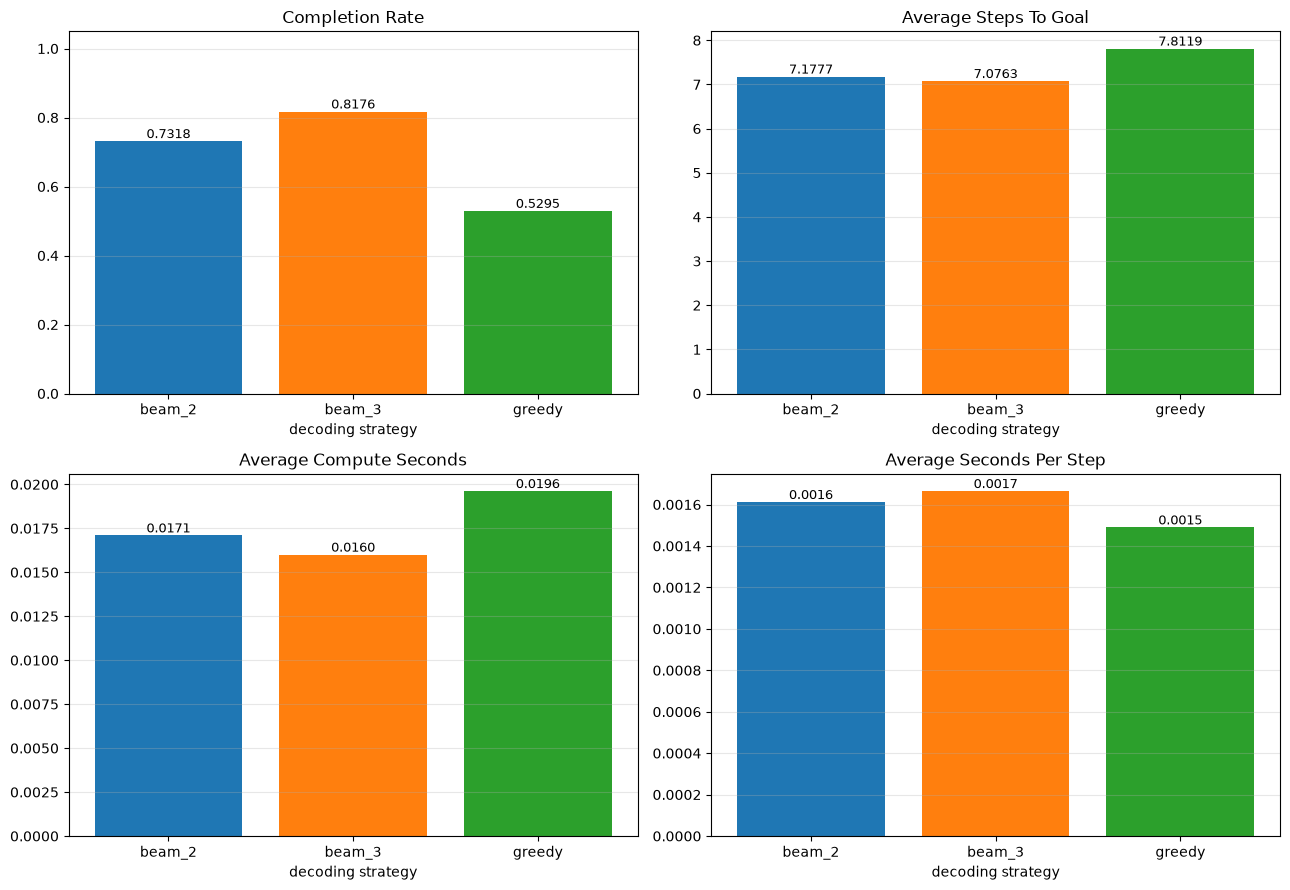

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metric_specs = [
    ("completion_rate", "Completion Rate"),
    ("average_steps_to_goal", "Average Steps To Goal"),
    ("average_compute_seconds", "Average Compute Seconds"),
    ("average_seconds_per_step", "Average Seconds Per Step"),
]

for ax, (metric, title) in zip(np.asarray(axes).ravel(), metric_specs):
    ax.bar(cv5_summary["strategy"], cv5_summary[metric], color=["tab:blue", "tab:orange", "tab:green"])
    ax.set_title(title)
    ax.set_xlabel("decoding strategy")
    ax.grid(axis="y", alpha=0.3)
    if metric == "completion_rate":
        ax.set_ylim(0.0, 1.05)
    for x_pos, value in enumerate(cv5_summary[metric]):
        ax.text(x_pos, float(value), f"{float(value):.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


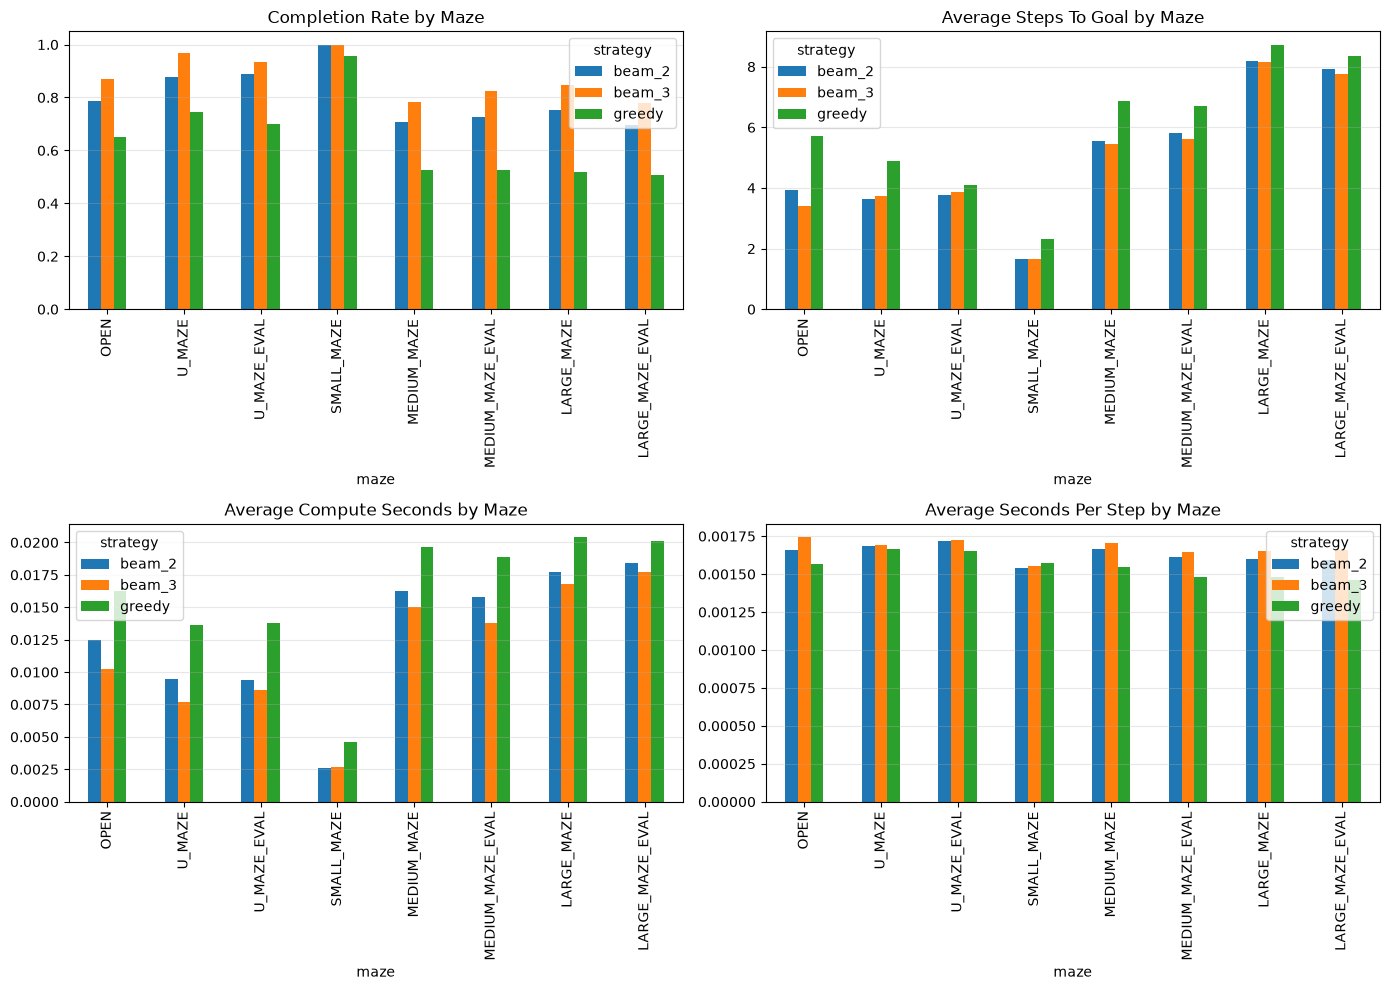

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
per_maze_plot = cv5_per_maze_summary.copy()
metric_specs = [
    ("completion_rate", "Completion Rate"),
    ("average_steps_to_goal", "Average Steps To Goal"),
    ("average_compute_seconds", "Average Compute Seconds"),
    ("average_seconds_per_step", "Average Seconds Per Step"),
]

for ax, (metric, title) in zip(np.asarray(axes).ravel(), metric_specs):
    pivot = per_maze_plot.pivot(index="maze_name", columns="strategy", values=metric).loc[DEFAULT_MAZES]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title + " by Maze")
    ax.set_xlabel("maze")
    ax.grid(axis="y", alpha=0.3)
    if metric == "completion_rate":
        ax.set_ylim(0.0, 1.05)

plt.tight_layout()
plt.show()


## Mixed-quality dataset: one trajectory per start-goal query


In [27]:
# Generate one organic epsilon-greedy trajectory for every existing start-goal query.
from collections import deque

MIXED_SOURCE_DATASET = Path("maze2d_all_mazes_transformer_ready_4act_cv5.npz")
MIXED_DATASET_PATH = Path("maze2d_all_mazes_transformer_ready_mixed_4act_cv5.npz")
MIXED_SEED = 20260802
MIXED_MAX_STEPS = 19
MIXED_EPSILON = 0.20  # At each step, choose randomly with 20% probability.


def mixed_neighbors(maze: np.ndarray, cell: tuple[int, int]) -> list[tuple[int, int]]:
    result = []
    for delta in ACTION_DELTAS:
        nxt = (cell[0] + int(delta[0]), cell[1] + int(delta[1]))
        if 0 <= nxt[0] < maze.shape[0] and 0 <= nxt[1] < maze.shape[1] and maze[nxt] == 0:
            result.append(nxt)
    return result


def mixed_distance_map(maze: np.ndarray, goal: tuple[int, int]) -> dict[tuple[int, int], int]:
    distances = {goal: 0}
    queue = deque([goal])
    while queue:
        cell = queue.popleft()
        for nxt in mixed_neighbors(maze, cell):
            if nxt not in distances:
                distances[nxt] = distances[cell] + 1
                queue.append(nxt)
    return distances


def mixed_rollout(maze, start, goal, distances, epsilon, rng):
    cell, path = start, [start]
    for _ in range(MIXED_MAX_STEPS):
        if cell == goal:
            break
        legal = [nxt for nxt in mixed_neighbors(maze, cell) if nxt in distances]
        if not legal:
            break
        best_distance = min(distances[nxt] for nxt in legal)
        best = [nxt for nxt in legal if distances[nxt] == best_distance]
        choices = legal if rng.random() < epsilon else best
        cell = choices[int(rng.integers(len(choices)))]
        path.append(cell)
    return np.asarray(path, dtype=np.int16), cell == goal


def generate_mixed_quality_dataset() -> Path:
    source = np.load(MIXED_SOURCE_DATASET, allow_pickle=True)
    rng = np.random.default_rng(MIXED_SEED)
    mazes_local = [np.asarray(maze, dtype=np.int8) for maze in source["mazes"]]
    maze_indices_local = np.asarray(source["maze_indices"], dtype=np.int32)
    starts = np.asarray(source["start_cells"], dtype=np.int16)
    goals = np.asarray(source["goal_cells"], dtype=np.int16)
    folds = np.asarray(source["fold_ids"], dtype=np.int32)
    optimal_paths = [np.asarray(path, dtype=np.int16) for path in source["paths_xy"]]
    maze_token_ids_local = np.asarray(source["maze_token_ids"], dtype=np.int32)
    global_shape = tuple(int(v) for v in source["global_grid_shape"])
    state_offset = int(source["state_token_offset"][0])
    action_offset = int(source["action_token_offset"][0])

    distance_cache, records = {}, []
    for index in range(len(starts)):
        maze_index = int(maze_indices_local[index])
        maze = mazes_local[maze_index]
        start = tuple(int(v) for v in starts[index])
        goal = tuple(int(v) for v in goals[index])
        cache_key = (maze_index, goal)
        if cache_key not in distance_cache:
            distance_cache[cache_key] = mixed_distance_map(maze, goal)
        distances = distance_cache[cache_key]
        optimal_path = optimal_paths[index]
        path, reached = mixed_rollout(maze, start, goal, distances, MIXED_EPSILON, rng)
        actual_steps = len(path) - 1
        optimal_steps = len(optimal_path) - 1
        if not reached:
            quality = "failed"
        elif actual_steps == optimal_steps:
            quality = "optimal"
        else:
            quality = "suboptimal"
        records.append({
            "index": index, "maze_index": maze_index, "fold": int(folds[index]),
            "optimal_path": optimal_path,
            "path": path, "reached": reached, "quality": quality,
        })

    packed_rows, selected_paths = [], []
    qualities, generators, epsilons, reached_values = [], [], [], []
    optimal_values, actual_values, excess_values, stretch_values = [], [], [], []

    for record in records:
        index = record["index"]
        optimal_path = record["optimal_path"]
        optimal_steps = len(optimal_path) - 1
        path = np.asarray(record["path"], dtype=np.int16)
        reached = bool(record["reached"])
        generator = "epsilon_greedy"
        epsilon = MIXED_EPSILON
        actual_steps = len(path) - 1
        packed_rows.append(build_tokenized_episode(
            maze_token_id=int(maze_token_ids_local[record["maze_index"]]),
            path_cells=path,
            goal_cell=goals[index],
            global_grid_shape=global_shape,
            state_token_offset=state_offset,
            action_token_offset=action_offset,
        ))
        selected_paths.append(path)
        qualities.append(record["quality"])
        generators.append(generator)
        epsilons.append(epsilon)
        reached_values.append(reached)
        optimal_values.append(optimal_steps)
        actual_values.append(actual_steps)
        excess_values.append(actual_steps - optimal_steps if reached else -1)
        stretch_values.append(actual_steps / optimal_steps if reached else np.nan)

    lengths = np.asarray([row["sequence_length"] for row in packed_rows], dtype=np.int32)
    row_count, max_length = len(packed_rows), int(lengths.max())
    input_ids_new = np.full((row_count, max_length), int(source["pad_token_id"][0]), dtype=np.int32)
    labels_new = np.full((row_count, max_length), -100, dtype=np.int32)
    attention_new = np.zeros((row_count, max_length), dtype=np.int8)
    types_new = np.full((row_count, max_length), int(source["token_type_pad"][0]), dtype=np.int8)

    for index, row in enumerate(packed_rows):
        length = int(row["sequence_length"])
        input_ids_new[index, :length] = row["input_ids"]
        labels_new[index, :length] = row["labels"]
        types_new[index, :length] = row["token_type_ids"]
        attention_new[index, :length] = 1

    output = {key: source[key] for key in source.files}
    output.update({
        "input_ids": input_ids_new,
        "labels": labels_new,
        "attention_mask": attention_new,
        "token_type_ids": types_new,
        "sequence_lengths": lengths,
        "path_lengths": np.asarray([len(path) for path in selected_paths], dtype=np.int32),
        "paths_xy": np.asarray(selected_paths, dtype=object),
        "trajectory_quality": np.asarray(qualities, dtype="<U16"),
        "generator_type": np.asarray(generators, dtype="<U32"),
        "generation_epsilon": np.asarray(epsilons, dtype=np.float32),
        "goal_reached": np.asarray(reached_values, dtype=np.bool_),
        "optimal_steps": np.asarray(optimal_values, dtype=np.int32),
        "actual_steps": np.asarray(actual_values, dtype=np.int32),
        "excess_steps": np.asarray(excess_values, dtype=np.int32),
        "path_stretch": np.asarray(stretch_values, dtype=np.float32),
        "query_ids": np.arange(row_count, dtype=np.int32),
        "mixed_generation_seed": np.asarray([MIXED_SEED], dtype=np.int64),
        "mixed_max_steps": np.asarray([MIXED_MAX_STEPS], dtype=np.int32),
    })
    np.savez_compressed(MIXED_DATASET_PATH, **output)
    print("mixed dataset:", MIXED_DATASET_PATH)
    print("records:", row_count, "source records:", source["input_ids"].shape[0])
    quality_counts = pd.Series(qualities).value_counts().reindex(["optimal", "suboptimal", "failed"], fill_value=0)
    quality_report = pd.DataFrame({
        "records": quality_counts,
        "proportion": quality_counts / row_count,
    })
    print(quality_report.to_string(formatters={"proportion": "{:.2%}".format}))
    return MIXED_DATASET_PATH


mixed_dataset_path = generate_mixed_quality_dataset()


mixed dataset: maze2d_all_mazes_transformer_ready_mixed_4act_cv5.npz
records: 5976 source records: 5976
            records proportion
optimal        3026     50.64%
suboptimal     2690     45.01%
failed          260      4.35%


In [28]:
# Confirm same queries, same record count, same folds, and compatibility with MazeTokenDataset.
mixed_data = np.load(mixed_dataset_path, allow_pickle=True)
mixed_source = np.load(MIXED_SOURCE_DATASET, allow_pickle=True)

assert mixed_data["input_ids"].shape[0] == mixed_source["input_ids"].shape[0]
assert np.array_equal(mixed_data["maze_indices"], mixed_source["maze_indices"])
assert np.array_equal(mixed_data["start_cells"], mixed_source["start_cells"])
assert np.array_equal(mixed_data["goal_cells"], mixed_source["goal_cells"])
assert np.array_equal(mixed_data["fold_ids"], mixed_source["fold_ids"])
assert np.all(mixed_data["attention_mask"].sum(axis=1) == mixed_data["sequence_lengths"])
assert np.all((mixed_data["labels"] != -100).sum(axis=1) == mixed_data["actual_steps"])

test_indices = np.arange(min(16, len(mixed_data["input_ids"])), dtype=np.int64)
mixed_compatibility_test = MazeTokenDataset(mixed_dataset_path, test_indices)
assert len(mixed_compatibility_test) == len(test_indices)

mixed_quality_summary = (
    pd.DataFrame({
        "maze_name": mixed_data["maze_name_per_episode"].astype(str),
        "fold": mixed_data["fold_ids"].astype(int),
        "quality": mixed_data["trajectory_quality"].astype(str),
        "goal_reached": mixed_data["goal_reached"].astype(bool),
        "optimal_steps": mixed_data["optimal_steps"].astype(int),
        "actual_steps": mixed_data["actual_steps"].astype(int),
    })
    .groupby(["maze_name", "fold", "quality"], as_index=False)
    .agg(
        records=("quality", "size"),
        completion_rate=("goal_reached", "mean"),
        mean_optimal_steps=("optimal_steps", "mean"),
        mean_actual_steps=("actual_steps", "mean"),
    )
)
print("Compatibility checks passed.")
print("shape:", mixed_data["input_ids"].shape)
print("fold counts:", np.bincount(mixed_data["fold_ids"]).tolist())
display(mixed_quality_summary)


Compatibility checks passed.
shape: (5976, 42)
fold counts: [1196, 1196, 1195, 1195, 1194]


,maze_name,fold,quality,records,completion_rate,mean_optimal_steps,mean_actual_steps
0,LARGE_MAZE,0,failed,30,0.0,14.000000,19.000000
1,LARGE_MAZE,0,optimal,187,1.0,6.058824,6.058824
2,LARGE_MAZE,0,suboptimal,197,1.0,8.746193,12.269036
3,LARGE_MAZE,1,failed,22,0.0,14.318182,19.000000
4,LARGE_MAZE,1,optimal,196,1.0,6.352041,6.352041
...,...,...,...,...,...,...,...
83,U_MAZE_EVAL,2,suboptimal,7,1.0,4.142857,6.428571
84,U_MAZE_EVAL,3,optimal,13,1.0,2.615385,2.615385
85,U_MAZE_EVAL,3,suboptimal,5,1.0,6.800000,9.200000
86,U_MAZE_EVAL,4,optimal,15,1.0,3.666667,3.666667


### Example optimal, suboptimal and failed trajectories

The plots below use the same mixed dataset consumed by the experiment. A star marks the goal; failed trajectories also show a red cross where the agent stopped.

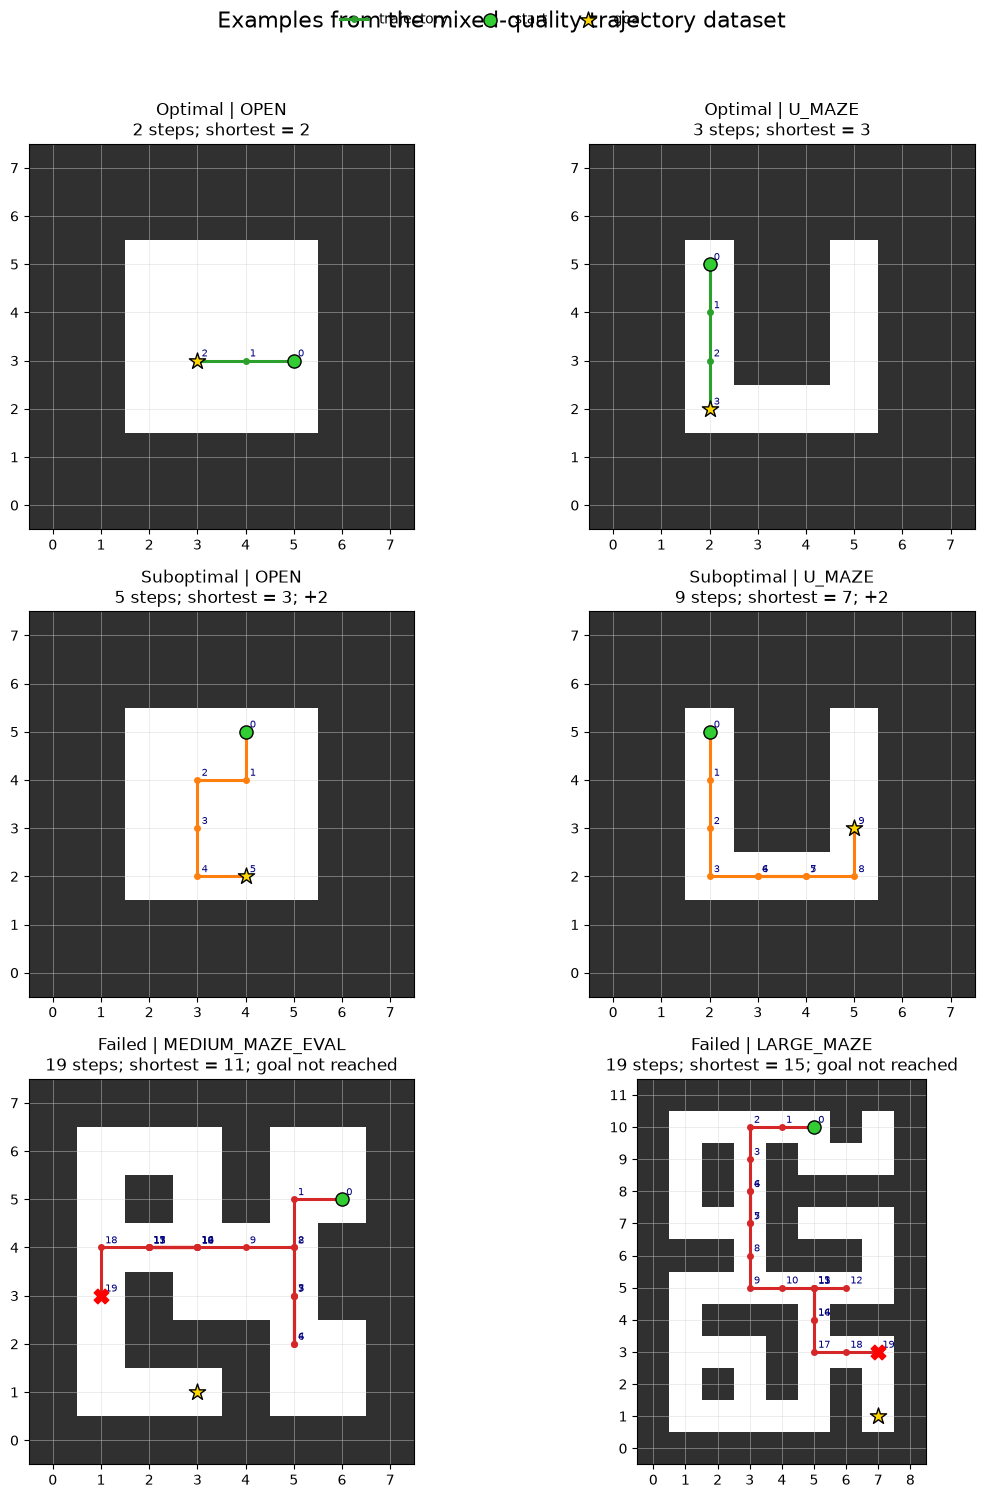

In [29]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

MIXED_EXAMPLES_PER_QUALITY = 2
MIXED_QUALITY_ORDER = ["optimal", "suboptimal", "failed"]
MIXED_QUALITY_COLOURS = {
    "optimal": "tab:green",
    "suboptimal": "tab:orange",
    "failed": "tab:red",
}


def choose_mixed_examples(data, quality, count=2):
    qualities = np.asarray(data["trajectory_quality"]).astype(str)
    candidates = np.flatnonzero(qualities == quality)
    maze_indices = np.asarray(data["maze_indices"], dtype=np.int32)
    actual_steps = np.asarray(data["actual_steps"], dtype=np.int32)
    query_ids = np.asarray(data["query_ids"], dtype=np.int32)
    candidates = candidates[np.lexsort((query_ids[candidates], actual_steps[candidates], maze_indices[candidates]))]

    # Prefer examples from different mazes so the display is not repetitive.
    selected = []
    for maze_index in np.unique(maze_indices[candidates]):
        maze_candidates = candidates[maze_indices[candidates] == maze_index]
        selected.append(int(maze_candidates[len(maze_candidates) // 2]))
        if len(selected) == count:
            break
    return selected


def plot_mixed_trajectory(ax, data, index, quality):
    maze_index = int(data["maze_indices"][index])
    maze = np.asarray(data["mazes"][maze_index], dtype=np.int8)
    path = np.asarray(data["paths_xy"][index], dtype=np.int16)
    start = np.asarray(data["start_cells"][index], dtype=np.int16)
    goal = np.asarray(data["goal_cells"][index], dtype=np.int16)
    maze_name = str(data["maze_name_per_episode"][index])
    actual_steps = int(data["actual_steps"][index])
    optimal_steps = int(data["optimal_steps"][index])
    colour = MIXED_QUALITY_COLOURS[quality]

    # Transpose because dataset cells are stored as (x, y), while imshow uses (row, column).
    ax.imshow(maze.T, origin="lower", cmap=ListedColormap(["white", "#303030"]), vmin=0, vmax=1)
    ax.plot(path[:, 0], path[:, 1], color=colour, linewidth=2.2, marker="o", markersize=4, label="trajectory")
    ax.scatter(start[0], start[1], s=90, color="limegreen", edgecolor="black", zorder=4, label="start")
    ax.scatter(goal[0], goal[1], s=150, color="gold", edgecolor="black", marker="*", zorder=5, label="goal")
    if quality == "failed":
        ax.scatter(path[-1, 0], path[-1, 1], s=110, color="red", marker="X", zorder=6, label="stopped")

    for step, cell in enumerate(path):
        ax.annotate(str(step), (cell[0], cell[1]), xytext=(3, 3), textcoords="offset points", fontsize=7, color="navy")

    detail = f"{actual_steps} steps; shortest = {optimal_steps}"
    if quality == "suboptimal":
        detail += f"; +{actual_steps - optimal_steps}"
    elif quality == "failed":
        detail += "; goal not reached"
    ax.set_title(f"{quality.title()} | {maze_name}\n{detail}")
    ax.set_xticks(range(maze.shape[0]))
    ax.set_yticks(range(maze.shape[1]))
    ax.grid(color="lightgray", linewidth=0.5, alpha=0.6)
    ax.set_aspect("equal")


fig, axes = plt.subplots(
    len(MIXED_QUALITY_ORDER),
    MIXED_EXAMPLES_PER_QUALITY,
    figsize=(6 * MIXED_EXAMPLES_PER_QUALITY, 5 * len(MIXED_QUALITY_ORDER)),
    squeeze=False,
)
for row, quality in enumerate(MIXED_QUALITY_ORDER):
    example_indices = choose_mixed_examples(mixed_data, quality, MIXED_EXAMPLES_PER_QUALITY)
    for column, index in enumerate(example_indices):
        plot_mixed_trajectory(axes[row, column], mixed_data, index, quality)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
fig.suptitle("Examples from the mixed-quality trajectory dataset", fontsize=16, y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


## Reproducibility check using the modular experiment runner

The cells below rerun the original main experiment on the **optimal four-action trajectory dataset** using the standalone configuration-driven pipeline. The reproduction uses the same five cross-validation folds, all eight maze layouts, 20 training epochs, model architecture, optimiser settings, random seed, three decoding strategies, and fixed 19-step decoding horizon as the original notebook experiment.

The new run writes to `experiment_runs/cv5_optimal_4act/`, so it does not overwrite the original checkpoints or result tables. Because this deliberately retrains all five folds, the first cell can take a substantial amount of time. Computational timings are expected to vary between runs; equivalence is assessed using the decoded outcomes and path lengths.

In [30]:
import subprocess
import sys

MODULAR_CONFIG_PATH = Path("experiment_configs/cv5_experiments.json")
MODULAR_EXPERIMENT_NAME = "cv5_optimal_4act"
MODULAR_OUTPUT_DIR = Path("experiment_runs") / MODULAR_EXPERIMENT_NAME

modular_command = [
    sys.executable,
    "run_dataset_experiments.py",
    "--config",
    str(MODULAR_CONFIG_PATH),
    "--experiment",
    MODULAR_EXPERIMENT_NAME,
    "--force",
]
print("Running:", subprocess.list2cmdline(modular_command))
subprocess.run(modular_command, check=True)
print("Modular reproduction completed:", MODULAR_OUTPUT_DIR)


Running: c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe run_dataset_experiments.py --config experiment_configs\cv5_experiments.json --experiment cv5_optimal_4act --force
Modular reproduction completed: experiment_runs\cv5_optimal_4act


### Comparison with the original notebook experiment

This comparison joins the original and modular per-query outputs using the fold, maze, episode and decoding strategy. It checks exact agreement in goal completion and number of decoded steps. Aggregate completion rate and average steps to goal should consequently agree. Compute-time columns are displayed but are not used as equivalence conditions because wall-clock measurements naturally fluctuate.

In [31]:
ORIGINAL_OPTIMAL_TAG = "cv5_4act19_all8"
ORIGINAL_RESULTS_PATH = Path(f"beam_search_benchmark_{ORIGINAL_OPTIMAL_TAG}_results.csv")
ORIGINAL_SUMMARY_PATH = Path(f"beam_search_benchmark_{ORIGINAL_OPTIMAL_TAG}_summary.csv")
MODULAR_RESULTS_PATH = MODULAR_OUTPUT_DIR / "results.csv"
MODULAR_SUMMARY_PATH = MODULAR_OUTPUT_DIR / "summary.csv"
MODULAR_MANIFEST_PATH = MODULAR_OUTPUT_DIR / "manifest.json"

required_paths = [
    ORIGINAL_RESULTS_PATH, ORIGINAL_SUMMARY_PATH,
    MODULAR_RESULTS_PATH, MODULAR_SUMMARY_PATH, MODULAR_MANIFEST_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"Missing reproduction files: {missing_paths}")

original_results = pd.read_csv(ORIGINAL_RESULTS_PATH)
modular_results = pd.read_csv(MODULAR_RESULTS_PATH)
original_summary = pd.read_csv(ORIGINAL_SUMMARY_PATH).sort_values("strategy").reset_index(drop=True)
modular_summary = pd.read_csv(MODULAR_SUMMARY_PATH).sort_values("strategy").reset_index(drop=True)
with MODULAR_MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    modular_manifest = json.load(handle)

join_columns = ["cv_fold", "maze_name", "episode_id", "strategy"]
outcome_columns = join_columns + ["goal_reached", "steps_until_stop"]
comparison = original_results[outcome_columns].merge(
    modular_results[outcome_columns],
    on=join_columns,
    how="outer",
    suffixes=("_original", "_modular"),
    indicator=True,
)
same_query_set = bool((comparison["_merge"] == "both").all())
same_completion = bool(
    same_query_set
    and (comparison["goal_reached_original"] == comparison["goal_reached_modular"]).all()
)
same_step_counts = bool(
    same_query_set
    and (comparison["steps_until_stop_original"] == comparison["steps_until_stop_modular"]).all()
)

metric_columns = [
    "completion_rate",
    "average_steps_to_goal",
    "average_compute_seconds",
    "average_seconds_per_step",
]
summary_comparison = original_summary[["strategy"] + metric_columns].merge(
    modular_summary[["strategy"] + metric_columns],
    on="strategy",
    suffixes=("_original", "_modular"),
)
for metric in metric_columns:
    summary_comparison[f"{metric}_difference"] = (
        summary_comparison[f"{metric}_modular"]
        - summary_comparison[f"{metric}_original"]
    )

configuration = modular_manifest["experiment"]
configuration_matches = (
    configuration["dataset"] == "maze2d_all_mazes_transformer_ready_4act_cv5.npz"
    and configuration["folds"] == [0, 1, 2, 3, 4]
    and configuration["evaluation"]["max_steps"] == 19
    and configuration["training"]["epochs"] == 20
    and configuration["training"]["seed"] == 7
    and configuration["mazes"] == list(DEFAULT_MAZES)
)

equivalence_report = pd.DataFrame({
    "check": [
        "configuration matches original experiment",
        "same evaluation query set",
        "same goal-completion outcomes",
        "same decoded step counts",
    ],
    "passed": [configuration_matches, same_query_set, same_completion, same_step_counts],
})
display(equivalence_report)
display(summary_comparison)

assert equivalence_report["passed"].all(), (
    "The modular reproduction did not exactly match the original decoded outcomes. "
    "Inspect the comparison tables before interpreting timing differences."
)
print("Equivalent decoded outcomes confirmed. Timing differences are expected.")


,check,passed
0,configuration matches original experiment,True
1,same evaluation query set,True
2,same goal-completion outcomes,True
3,same decoded step counts,True


,strategy,completion_rate_original,average_steps_to_goal_original,average_compute_seconds_original,average_seconds_per_step_original,completion_rate_modular,average_steps_to_goal_modular,average_compute_seconds_modular,average_seconds_per_step_modular,completion_rate_difference,average_steps_to_goal_difference,average_compute_seconds_difference,average_seconds_per_step_difference
0,beam_2,0.909973,7.077050,0.014012,0.001670,0.909973,7.077050,0.018944,0.002321,0.0,0.0,0.004933,0.000651
1,beam_3,0.975402,6.905816,0.012976,0.001735,0.975402,6.905816,0.017351,0.002385,0.0,0.0,0.004376,0.000650
2,greedy,0.691600,7.720542,0.017658,0.001547,0.691600,7.720542,0.024313,0.002168,0.0,0.0,0.006655,0.000621


Equivalent decoded outcomes confirmed. Timing differences are expected.


## Partial-observation extension: 3x3 local view

This experiment changes the information supplied to the Transformer while keeping the original optimal trajectories, maze set, five-fold start–goal split, model hyperparameters, action set, and 19-step evaluation horizon fixed. The maze identifier and absolute coordinates are removed. At each decision point the model receives: (1) a north-aligned $3\times3$ wall neighbourhood, (2) the visible position of the goal when it lies inside that neighbourhood, and (3) the goal displacement $(r_g-r_t,c_g-c_t)$ relative to the agent's current position. The relative displacement is repeated because it changes after every action. The centre of the neighbourhood is always the agent; consequently, no absolute starting coordinate is supplied.

The neighbourhood is encoded losslessly and compactly using a nine-bit wall mask plus a ten-valued visible-goal token (not visible, or one of nine cells). Separate row- and column-displacement tokens complete the observation. Only action tokens are supervised, and all training trajectories remain optimal.

The fold IDs are copied directly from the fully observed dataset. Therefore, for every fold, the held-out start–goal pairs are exactly the same pairs used previously. This stage tests performance on unseen start–goal combinations in **known maze layouts**; it does not yet test unseen-maze generalisation.


In [33]:
from pathlib import Path
import subprocess
import sys

project_dir = Path.cwd()
partial_dataset = project_dir / "maze2d_partial_obs_3x3_optimal_4act_cv5.npz"

subprocess.run(
    [sys.executable, "build_partial_observation_cv_dataset.py",
     "--source", "maze2d_all_mazes_transformer_ready_4act_cv5.npz",
     "--output", str(partial_dataset)],
    cwd=project_dir,
    check=True,
)

subprocess.run(
    [sys.executable, "run_dataset_experiments.py",
     "--experiment", "cv5_partial_obs_3x3_optimal_4act"],
    cwd=project_dir,
    check=True,
)


CompletedProcess(args=['c:\\Users\\User\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe', 'run_dataset_experiments.py', '--experiment', 'cv5_partial_obs_3x3_optimal_4act'], returncode=0)

### Important decoding distinction

Greedy decoding is a genuine closed-loop partial-observation policy: it selects one valid action from the current history, executes it, receives the next real local observation, and repeats. To keep beam search comparable to the original experiment, beam widths 2 and 3 expand candidate paths with the known maze simulator. The simulator supplies the local observation that would be seen at each hypothetical candidate cell and rejects wall moves. Thus the Transformer itself still receives no maze ID, full map, or absolute coordinate, but beam search has privileged counterfactual access to the known environment during planning. Beam results in this section must therefore be described as **simulator-assisted partial-observation planning**, not as strictly online planning in an unknown maze. A later unseen-maze experiment will need learned observation prediction or a different online search formulation to avoid that oracle.


In [35]:
import numpy as np
import pandas as pd
from IPython.display import display

result_dir = Path("experiment_runs/cv5_partial_obs_3x3_optimal_4act")
summary = pd.read_csv(result_dir / "summary.csv")
fold_results = pd.read_csv(result_dir / "fold_mean_std.csv")
per_maze = pd.read_csv(result_dir / "per_maze_summary.csv")

with np.load(partial_dataset, allow_pickle=True) as data:
    original = np.load("maze2d_all_mazes_transformer_ready_4act_cv5.npz", allow_pickle=True)
    assert np.array_equal(data["episode_ids"], original["episode_ids"])
    assert np.array_equal(data["fold_ids"], original["fold_ids"])
    assert np.array_equal(data["start_cells"], original["start_cells"])
    assert np.array_equal(data["goal_cells"], original["goal_cells"])
    print("Episodes:", data["input_ids"].shape[0])
    print("Maximum token sequence length:", data["input_ids"].shape[1])
    print("Fold counts:", np.bincount(data["fold_ids"]))
    original.close()

display(summary.style.format({
    "completion_rate": "{:.2%}",
    "average_steps_to_goal": "{:.3f}",
    "average_compute_seconds": "{:.5f}",
    "average_seconds_per_step": "{:.5f}",
}))
display(fold_results)
per_maze_metrics = per_maze[[
    "maze_name",
    "strategy",
    "completion_rate",
    "average_steps_to_goal",
    "average_compute_seconds",
    "average_seconds_per_step",
]].sort_values(["maze_name", "strategy"])

display(per_maze_metrics.style.format({
    "completion_rate": "{:.2%}",
    "average_steps_to_goal": "{:.3f}",
    "average_compute_seconds": "{:.5f}",
    "average_seconds_per_step": "{:.5f}",
}))

display(per_maze.pivot(index="maze_name", columns="strategy", values="completion_rate")
        .style.format("{:.2%}"))


Episodes: 5976
Maximum token sequence length: 100
Fold counts: [1196 1196 1195 1195 1194]


,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,beam_2,99.67%,6.878,0.03913,0.00556
1,beam_3,99.85%,6.825,0.04745,0.00665
2,greedy,96.77%,7.194,0.03243,0.00436


,strategy,completion_rate_mean,completion_rate_std,average_steps_to_goal_mean,average_steps_to_goal_std,average_compute_seconds_mean,average_compute_seconds_std,average_seconds_per_step_mean,average_seconds_per_step_std
0,beam_2,0.996654,0.001563,6.877772,0.019541,0.039128,0.009277,0.005560,0.001399
1,beam_3,0.998494,0.000916,6.824534,0.015608,0.047451,0.010882,0.006649,0.001556
2,greedy,0.967706,0.009228,7.193976,0.049968,0.032430,0.007834,0.004360,0.001118


,maze_name,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,LARGE_MAZE,beam_2,99.71%,8.001,0.04432,0.00534
1,LARGE_MAZE,beam_3,99.95%,7.955,0.05390,0.00638
2,LARGE_MAZE,greedy,95.46%,8.202,0.03588,0.00410
3,LARGE_MAZE_EVAL,beam_2,99.35%,7.619,0.04453,0.00572
4,LARGE_MAZE_EVAL,beam_3,99.63%,7.561,0.05485,0.00707
5,LARGE_MAZE_EVAL,greedy,96.72%,7.923,0.03619,0.00445
6,MEDIUM_MAZE,beam_2,100.00%,5.120,0.02842,0.00549
7,MEDIUM_MAZE,beam_3,100.00%,5.098,0.03430,0.00647
8,MEDIUM_MAZE,greedy,99.08%,5.658,0.02544,0.00446
9,MEDIUM_MAZE_EVAL,beam_2,100.00%,5.206,0.02953,0.00545


strategy,beam_2,beam_3,greedy
maze_name,,,
LARGE_MAZE,99.71%,99.95%,95.46%
LARGE_MAZE_EVAL,99.35%,99.63%,96.72%
MEDIUM_MAZE,100.00%,100.00%,99.08%
MEDIUM_MAZE_EVAL,100.00%,100.00%,96.62%
OPEN,100.00%,100.00%,100.00%
SMALL_MAZE,100.00%,100.00%,100.00%
U_MAZE,100.00%,100.00%,100.00%
U_MAZE_EVAL,100.00%,100.00%,100.00%


### Results

Across all five held-out folds (5,976 start–goal queries per strategy), greedy decoding reached the goal in **96.77%** of cases, with 7.194 steps on successful episodes. Simulator-assisted beam search improved completion to **99.67%** for beam width 2 and **99.85%** for beam width 3, while successful paths averaged 6.878 and 6.825 steps respectively. Mean decoding time increased from 0.03243 seconds per greedy query to 0.03913 seconds for beam 2 and 0.04745 seconds for beam 3.

These results show that removing the explicit maze identifier and absolute coordinates does not prevent strong performance on held-out start–goal pairs from known layouts. The Transformer can use its observation–action history, local geometry, and current goal displacement to choose effective actions. However, this experiment alone does not establish unseen-layout generalisation: the same eight layouts occur in the training portions of every fold. In addition, the beam advantage partly measures access to counterfactual local observations supplied by the known-maze simulator. The clean conclusion is therefore that the proposed partial observation is sufficient for strong closed-loop greedy behaviour on known layouts, while simulator-assisted search further improves reliability at additional computational cost.


## Joint action-state supervision and receding-horizon planning

This controlled extension returns to the original fully observed representation and optimal trajectories. It uses the same 5,976 episodes, maze identifiers, coordinate-state tokens, four actions, and five-fold start–goal assignments as the original experiment. The only training change is that the causal loss is now applied to both each expert action $a_t$ and the following coordinate state $s_{t+1}$. Thus the model learns

$$p(a_t\mid \tau_{\leq t}) \quad\text{and}\quad p(s_{t+1}\mid \tau_{\leq t},a_t).$$

The initial maze, start, goal, and current-state tokens remain context rather than prediction targets. There are 40,666 action targets and 40,666 post-action state targets. Because the state is an absolute coordinate and the maze identifier uniquely identifies a training layout, this remains the fully observed known-layout experiment.


In [36]:
from pathlib import Path
import subprocess
import sys

project_dir = Path.cwd()
joint_dataset = project_dir / "maze2d_all_mazes_joint_state_action_4act_cv5.npz"

subprocess.run(
    [sys.executable, "build_joint_state_action_cv_dataset.py",
     "--source", "maze2d_all_mazes_transformer_ready_4act_cv5.npz",
     "--output", str(joint_dataset)],
    cwd=project_dir,
    check=True,
)

subprocess.run(
    [sys.executable, "run_dataset_experiments.py",
     "--experiment", "cv5_joint_state_receding_4act"],
    cwd=project_dir,
    check=True,
)


CompletedProcess(args=['c:\\Users\\User\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe', 'run_dataset_experiments.py', '--experiment', 'cv5_joint_state_receding_4act'], returncode=0)

### Predicted-state planning procedure

At every real decision point, the decoder constructs a five-step imagined plan. A branch alternates between an action predicted by the model and a next coordinate state predicted by the model; the evaluator does not insert the true future state into an imagined branch. Beam widths 1, 2, and 3 are called `receding_greedy`, `receding_beam_2`, and `receding_beam_3`. Candidate actions are restricted to moves that are valid from the branch's predicted coordinate in the known maze, while predicted states are selected from the maze's free-cell coordinate tokens. The joint log-probability of actions and states ranks branches.

Only the first action of the selected plan is executed. The environment then returns the actual next coordinate, that real state replaces the predicted state in the permanent history, and the entire five-step plan is recomputed. This is closed-loop, receding-horizon planning: prediction errors can affect the current decision, but they do not permanently corrupt the trajectory history.

The trained positional encoding supports 42 tokens. If real history plus an imagined rollout exceeds this limit, inference retains the three fixed prompt tokens (maze, start, and goal) and the newest history tokens. Consequently, evaluation never uses a longer context than training.


In [37]:
import numpy as np
import pandas as pd
from IPython.display import display

joint_result_dir = Path("experiment_runs/cv5_joint_state_receding_4act")
joint_summary = pd.read_csv(joint_result_dir / "summary.csv")
joint_fold_stats = pd.read_csv(joint_result_dir / "fold_mean_std.csv")
joint_per_maze = pd.read_csv(joint_result_dir / "per_maze_summary.csv")

with np.load(joint_dataset, allow_pickle=True) as joint_data, np.load(
    "maze2d_all_mazes_transformer_ready_4act_cv5.npz", allow_pickle=True
) as original_data:
    for key in ("episode_ids", "fold_ids", "start_cells", "goal_cells", "input_ids"):
        assert np.array_equal(joint_data[key], original_data[key])
    action_targets = int(joint_data["supervised_action_mask"].sum())
    state_targets = int(joint_data["supervised_state_mask"].sum())
    print("Episodes:", len(joint_data["episode_ids"]))
    print("Fold counts:", np.bincount(joint_data["fold_ids"]))
    print("Supervised action tokens:", action_targets)
    print("Supervised post-action state tokens:", state_targets)

metric_formats = {
    "completion_rate": "{:.2%}",
    "average_steps_to_goal": "{:.3f}",
    "average_compute_seconds": "{:.5f}",
    "average_seconds_per_step": "{:.5f}",
    "first_predicted_state_accuracy": "{:.2%}",
    "imagined_transition_consistency": "{:.2%}",
}
display(joint_summary.style.format(metric_formats))
display(joint_fold_stats)
display(joint_per_maze.style.format(metric_formats))
display(joint_per_maze.pivot(index="maze_name", columns="strategy", values="completion_rate")
        .style.format("{:.2%}"))


Episodes: 5976
Fold counts: [1196 1196 1195 1195 1194]
Supervised action tokens: 40666
Supervised post-action state tokens: 40666


,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step,first_predicted_state_accuracy,imagined_transition_consistency
0,receding_beam_2,84.79%,7.089,0.21903,0.02017,91.92%,92.63%
1,receding_beam_3,89.78%,6.993,0.20900,0.02059,88.72%,91.06%
2,receding_greedy,63.10%,7.647,0.29163,0.02119,89.43%,86.27%


,strategy,completion_rate_mean,completion_rate_std,average_steps_to_goal_mean,average_steps_to_goal_std,average_compute_seconds_mean,average_compute_seconds_std,average_seconds_per_step_mean,average_seconds_per_step_std,first_predicted_state_accuracy_mean,first_predicted_state_accuracy_std,imagined_transition_consistency_mean,imagined_transition_consistency_std
0,receding_beam_2,0.847895,0.009665,7.089009,0.065702,0.219043,0.039756,0.020169,0.003797,0.919249,0.003278,0.926258,0.003069
1,receding_beam_3,0.897762,0.007590,6.993214,0.026748,0.209016,0.033265,0.020589,0.003568,0.887209,0.006160,0.910589,0.003143
2,receding_greedy,0.631032,0.030425,7.646473,0.098511,0.291656,0.059730,0.021193,0.004198,0.894264,0.004110,0.862711,0.006973


,maze_name,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step,first_predicted_state_accuracy,imagined_transition_consistency
0,LARGE_MAZE,receding_beam_2,83.04%,7.973,0.24154,0.02091,93.53%,93.56%
1,LARGE_MAZE,receding_beam_3,89.47%,7.964,0.23072,0.02140,90.26%,92.16%
2,LARGE_MAZE,receding_greedy,60.05%,8.320,0.30855,0.02165,92.64%,88.35%
3,LARGE_MAZE_EVAL,receding_beam_2,84.04%,7.889,0.24936,0.02174,92.93%,93.58%
4,LARGE_MAZE_EVAL,receding_beam_3,88.25%,7.785,0.24549,0.02243,89.51%,91.77%
5,LARGE_MAZE_EVAL,receding_greedy,59.07%,8.464,0.32552,0.02258,89.65%,86.73%
6,MEDIUM_MAZE,receding_beam_2,85.38%,5.605,0.17108,0.01804,87.86%,89.87%
7,MEDIUM_MAZE,receding_beam_3,89.38%,5.466,0.16338,0.01849,84.60%,87.72%
8,MEDIUM_MAZE,receding_greedy,70.31%,6.545,0.23413,0.01901,85.21%,83.95%
9,MEDIUM_MAZE_EVAL,receding_beam_2,84.92%,5.611,0.18638,0.01933,88.25%,89.74%


strategy,receding_beam_2,receding_beam_3,receding_greedy
maze_name,,,
LARGE_MAZE,83.04%,89.47%,60.05%
LARGE_MAZE_EVAL,84.04%,88.25%,59.07%
MEDIUM_MAZE,85.38%,89.38%,70.31%
MEDIUM_MAZE_EVAL,84.92%,90.92%,64.92%
OPEN,95.00%,97.92%,80.00%
SMALL_MAZE,100.00%,100.00%,100.00%
U_MAZE,91.11%,93.33%,78.89%
U_MAZE_EVAL,100.00%,100.00%,94.44%


### Results and interpretation

Across all 5,976 held-out start–goal queries, receding greedy reached the goal in **63.10%** of cases. Receding beam search improved completion to **84.79%** with width 2 and **89.78%** with width 3. Among successful trajectories, the respective mean path lengths were 7.647, 7.089, and 6.993 steps. Mean computation per query was 0.29163 seconds for receding greedy, 0.21903 seconds for beam 2, and 0.20900 seconds for beam 3. The apparently lower total time for wider beams occurs because those strategies succeed earlier and therefore invoke fewer replanning cycles; time per executed step is similar at approximately 0.020--0.021 seconds.

The first predicted next state matched the state produced by the selected action in **89.43%** of receding-greedy decisions, **91.92%** for beam 2, and **88.72%** for beam 3. Across all imagined transitions in selected plans, action-state consistency was **86.27%**, **92.63%**, and **91.06%**, respectively. These diagnostics confirm that the model usually learns the deterministic transition, but occasional inconsistent state predictions can mislead the planner.

Performance is substantially below the earlier teacher-forced-state decoder, especially for greedy decoding. This difference is expected and important: the earlier beam experiment inserted exact states along every hypothetical branch, whereas this experiment must assign probability to both actions and its own predicted future states and then repeatedly recover from prediction error. Beam search helps by retaining several action-state hypotheses. The clean conclusion is that joint state prediction enables genuinely model-generated rollouts and closed-loop replanning, but compounds model error and adds considerable computation; wider beams recover much of the lost reliability without matching the oracle-state experiment.


In [ ]:
print("I work and have access.")